# Import Library

In [263]:
from PIL import Image
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision
from rfdetr import RFDETRBase
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import json
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

# Load Model

In [244]:
model = RFDETRBase(pretrain_weights="E:\FOLDER TUGAS AKHIR 2\Football2\models\RFDETR Result Dataset With Augmentation Version 1\checkpoint_best_total.pth")
model.optimize_for_inference()

[2026-03-16 01:05:59] [WARNING] rf-detr - Reinitializing detection head: checkpoint has 4 classes, configured for 90.


------------------------
# Load Dataset

In [245]:
# Path dataset
dataset_path = "E:\FOLDER TUGAS AKHIR 2\Football2\Football Dataset with Augmentation Version 1 (RF-DETR)"

# Load COCO dataset
ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset_path}/test",
    annotations_path=f"{dataset_path}/test/_annotations.coco.json",
)

------------------------
# Prediksi Model

In [246]:
targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 50/50 [00:24<00:00,  2.06it/s]


---------------
# Hitung mAP

In [247]:
map_metric = MeanAveragePrecision()
map_metric.update(predictions, targets)
map_result = map_metric.compute()
print(map_result)

Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.547
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.783
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.620
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.547
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ]                 = 0.942
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ]                 = -1.000


--------------------------------------------------------
# Hitung Precision dan Recall

In [248]:
TP = 0
FP = 0
FN = 0

for gt, pred in zip(targets, predictions):

    if len(pred) == 0:
        FN += len(gt)
        continue

    iou = sv.box_iou_batch(pred.xyxy, gt.xyxy)

    matched_gt = set()

    for i in range(len(pred)):
        best_match = np.argmax(iou[i])
        best_iou = iou[i][best_match]

        if best_iou >= 0.5 and best_match not in matched_gt:
            if pred.class_id[i] == gt.class_id[best_match]:
                TP += 1
                matched_gt.add(best_match)
            else:
                FP += 1
        else:
            FP += 1

    FN += len(gt) - len(matched_gt)

precision = TP / (TP + FP + 1e-6)
recall = TP / (TP + FN + 1e-6)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.05246666666316889
Recall: 0.9087759804748545


**Penjelasan:**

Recall tinggi (0.91) berarti:
- Model berhasil menemukan sebagian besar objek yang benar (ball, player, referee, goalkeeper).
- Artinya hampir semua objek di gambar berhasil terdeteksi.


Precision sangat rendah (0.05) berarti:
- Banyak sekali False Positive.
- Model sering mendeteksi objek yang sebenarnya tidak ada.

---------------
# Cek Output Mentah Model

In [249]:
path, image_np, annotations = ds[0]
image = Image.open(path)
detections = model.predict(image, threshold=0.1) # Threshold rendah agar semua muncul

print("ID Kelas yang terdeteksi oleh model:", np.unique(detections.class_id))
print("Daftar kelas di dataset (ds.classes):", ds.classes)

ID Kelas yang terdeteksi oleh model: [ 2  3  4  7  8  9 12 13 14 17 18 19 22 23 24 27 28 29 32 33 34 37 38 39
 42 43 44 47 48 49 52 53 54 57 58 59 62 63 64 67 68 69 72 73 74 77 78 79
 82 83 84 87 88 89]
Daftar kelas di dataset (ds.classes): ['player-ball-goalkeeper-referee-QfA4', 'ball', 'goalkeeper', 'player', 'referee']


In [250]:
print(type(ds.classes))
print(ds.classes)

<class 'list'>
['player-ball-goalkeeper-referee-QfA4', 'ball', 'goalkeeper', 'player', 'referee']


--------------
# Run Inference with Fine-tuned RF-DETR Model

Nama kelas berdasarkan ds.classes: ['ball', 'goalkeeper', 'player', 'referee']
Menampilkan perbandingan Ground Truth vs Prediction untuk 5 gambar...


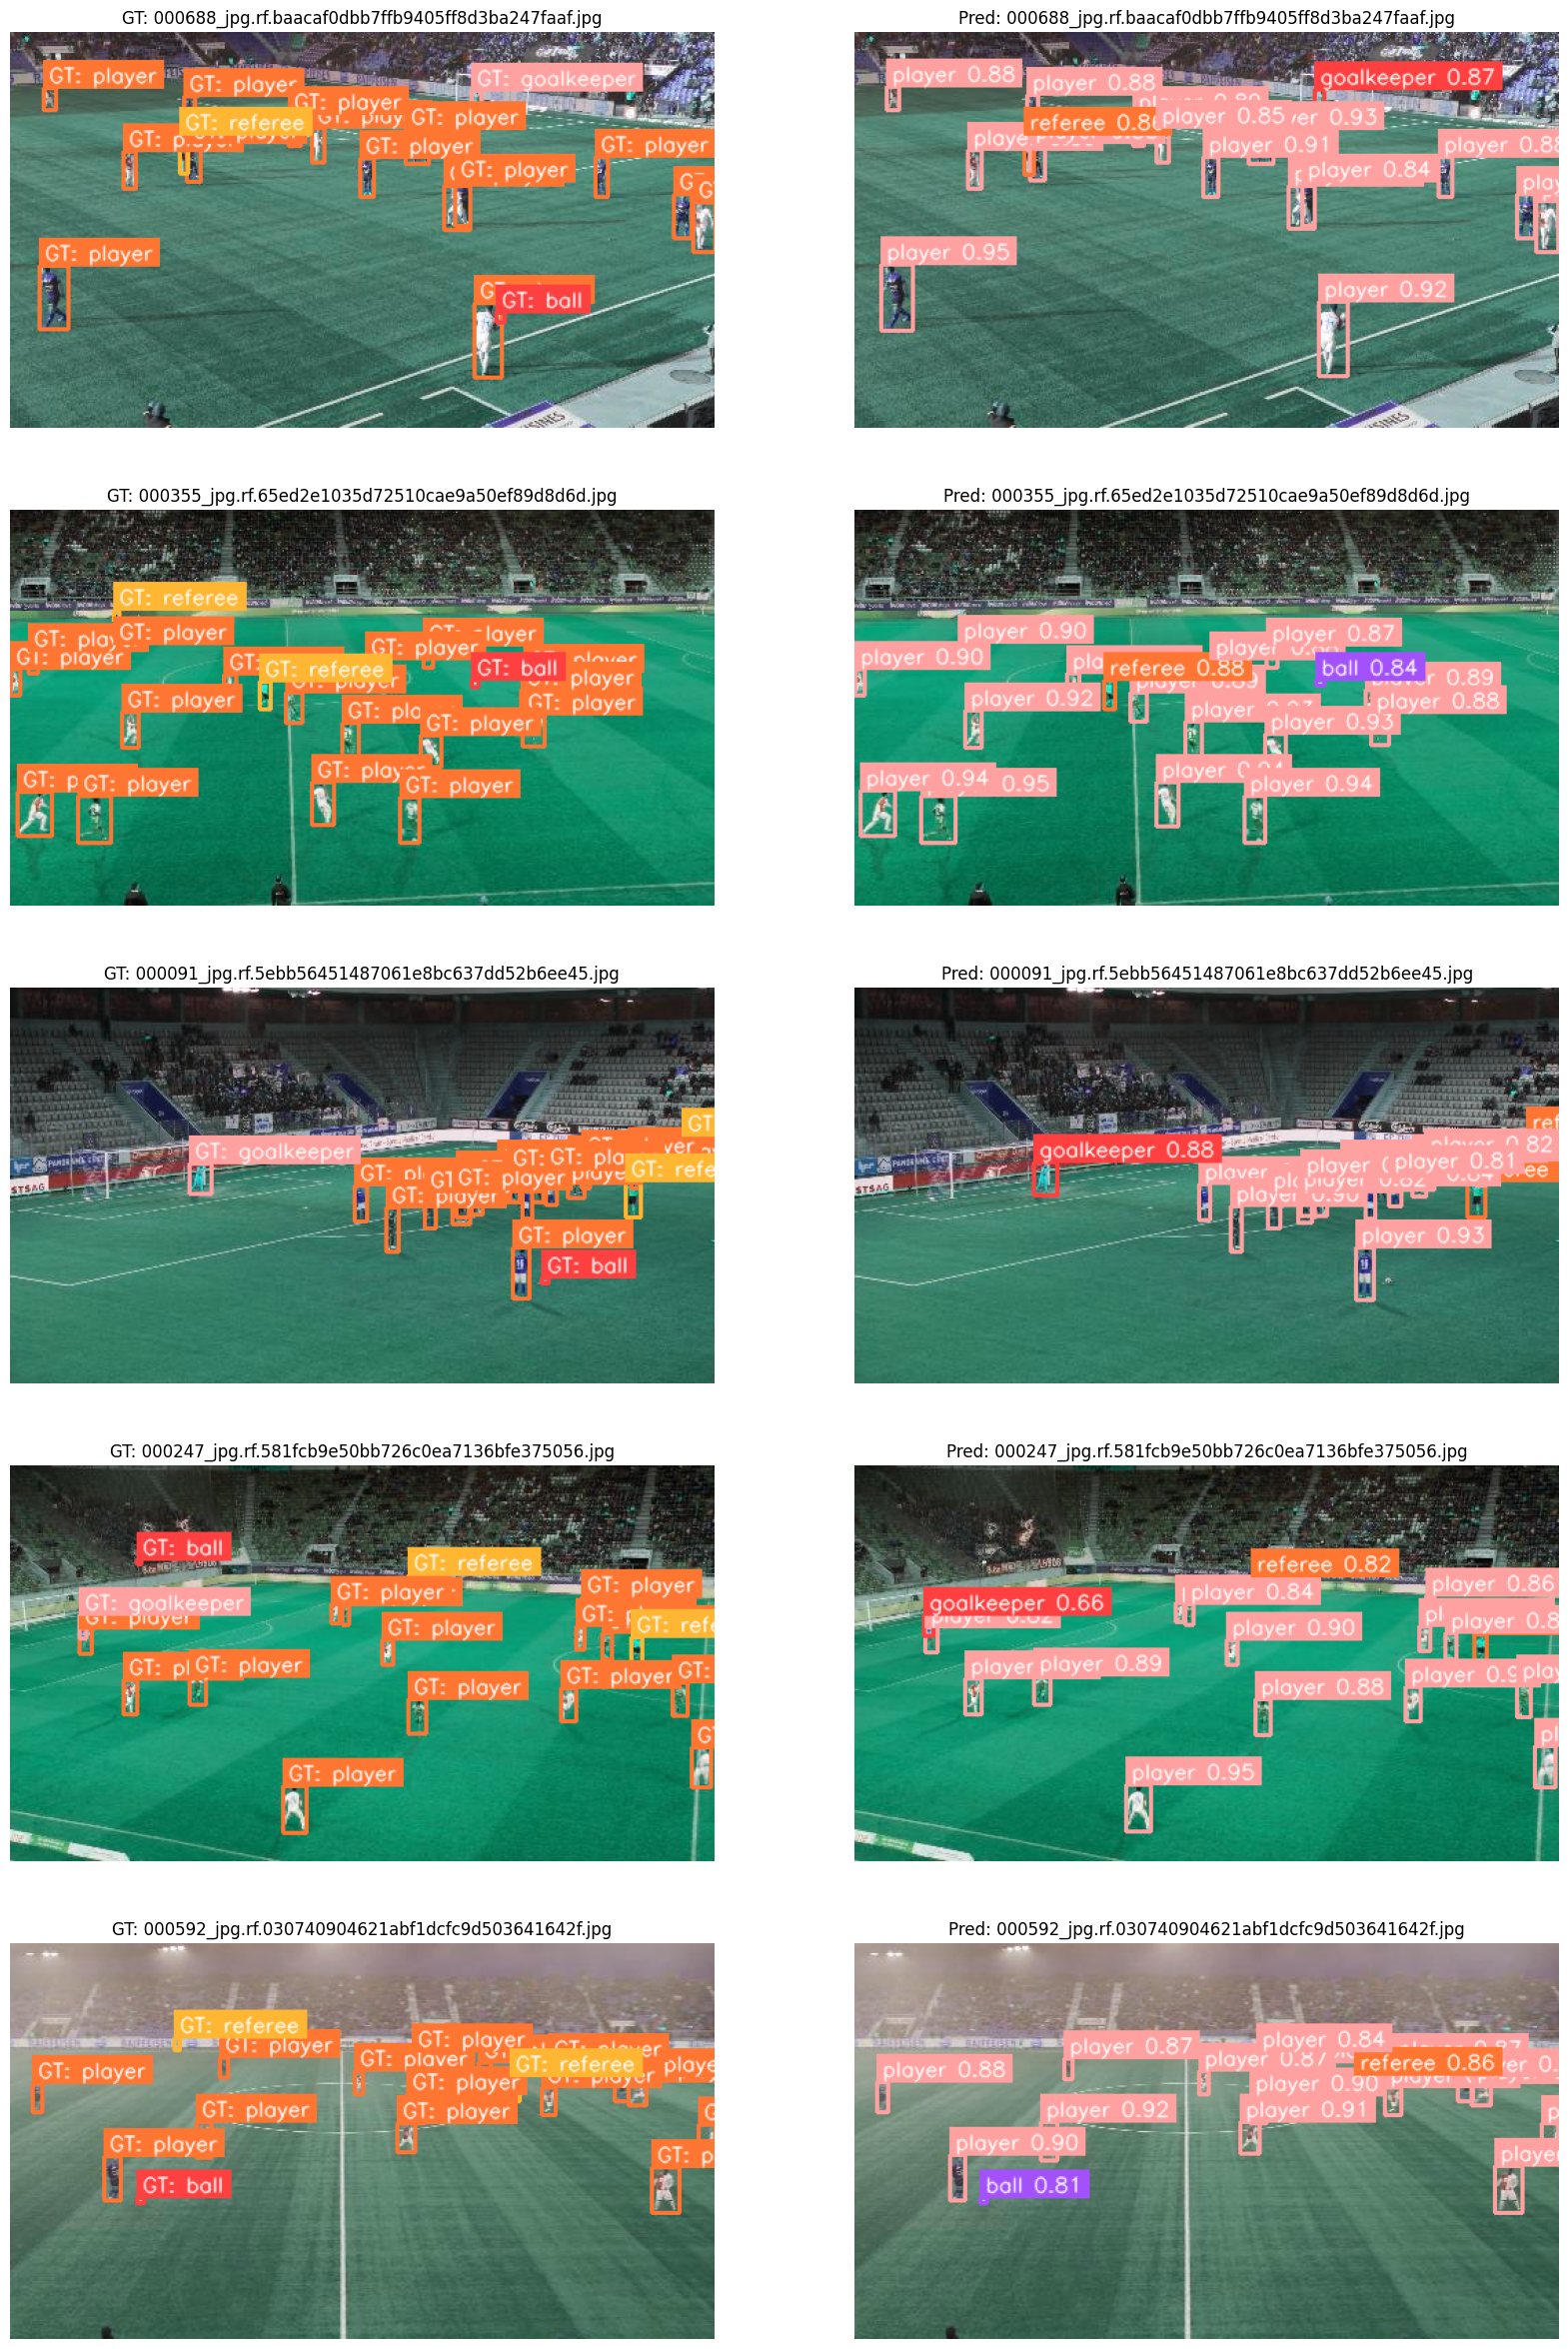

In [251]:
full_classes = ds.classes          # ['player-ball-...', 'ball', 'goalkeeper', 'player', 'referee']
class_names  = full_classes[1:]    # ['ball', 'goalkeeper', 'player', 'referee']
print("Nama kelas berdasarkan ds.classes:", class_names)

# List untuk menampung gambar yang akan ditampilkan di grid
images_to_plot = []
titles_to_plot = []

for i, (path, image_np, annotations) in enumerate(ds):
    if i >= 5: 
        break
    
    file_name = os.path.basename(path)
    image = Image.open(path)
    img_array = np.array(image)

    # --- 1. PROSES GROUND TRUTH ---
    gt_annotated = box_annotator.annotate(scene=img_array.copy(), detections=annotations)
    gt_labels = [f"GT: {class_names[int(class_id) - 1]}" for class_id in annotations.class_id]
    gt_annotated = label_annotator.annotate(scene=gt_annotated, detections=annotations, labels=gt_labels)
    
    # --- 2. PROSES PREDICTION ---
    detections = model.predict(image, threshold=0.3) 
    
    new_class_ids = []
    pred_labels = []
    for class_id, confidence in zip(detections.class_id, detections.confidence):
        mapped_id = (int(class_id) % len(full_classes)) - 1  # % 5 dinamis, lalu - 1
        new_class_ids.append(mapped_id)
        name = class_names[mapped_id]
        pred_labels.append(f"{name} {confidence:.2f}")
    
    detections.class_id = np.array(new_class_ids)
    
    pred_annotated = box_annotator.annotate(scene=img_array.copy(), detections=detections)
    pred_annotated = label_annotator.annotate(scene=pred_annotated, detections=detections, labels=pred_labels)

    images_to_plot.extend([gt_annotated, pred_annotated])
    titles_to_plot.extend([f"GT: {file_name}", f"Pred: {file_name}"])

print(f"Menampilkan perbandingan Ground Truth vs Prediction untuk 5 gambar...")
sv.plot_images_grid(
    images=images_to_plot, 
    titles=titles_to_plot, 
    grid_size=(len(images_to_plot)//2, 2), 
    size=(20, 6 * (len(images_to_plot)//2))
)

*Analisis Masalah: Kelas Dummy dari Roboflow Export*

Masalahnya sudah terlihat sangat jelas setelah kita print `ds.classes`. Ada **elemen tak terduga** di posisi paling awal daftar kelas:
```python
['player-ball-goalkeeper-referee-QfA4', 'ball', 'goalkeeper', 'player', 'referee']
```

* **Yang kita harapkan:** 4 kelas saja (`ball`, `goalkeeper`, `player`, `referee`)
* **Kenyataannya:** ada 5 elemen, dengan elemen pertama adalah nama aneh gabungan semua kelas.


##### 1. Masalah Utama: "Kelas Hantu" dari Roboflow

Saat dataset di-export dari **Roboflow** ke format COCO JSON, Roboflow secara otomatis membuat satu kategori tambahan di indeks 0 yang berisi gabungan semua nama kelas:
```
Indeks 0: 'player-ball-goalkeeper-referee-QfA4'  ← kelas dummy/artifact
Indeks 1: 'ball'
Indeks 2: 'goalkeeper'
Indeks 3: 'player'
Indeks 4: 'referee'
```

Kelas di indeks 0 ini **tidak pernah dipakai** oleh model maupun anotasi — ini murni artifact dari proses export. Tapi keberadaannya membuat panjang `ds.classes` menjadi **5**, bukan 4.

Itulah juga kenapa solusi `% 5` sebelumnya benar — bukan karena ada "stride internal COCO", tapi karena `ds.classes` memang punya 5 elemen!


##### 2. Solusi: Pisahkan `full_classes` dan `class_names`

Kita perlu dua variabel yang berbeda untuk dua keperluan berbeda:
```python
full_classes = ds.classes       # Panjang 5 — dipakai untuk operasi MODULO
class_names  = full_classes[1:] # Panjang 4 — dipakai untuk LOOKUP nama kelas
```

**Kenapa `full_classes` untuk modulo?**

Karena pola ID yang dikeluarkan model mengikuti panjang `full_classes` (yaitu 5):

| Raw ID dari model | `% 5` | `- 1` | Kelas |
|:-----------------:|:-----:|:-----:|-------|
| 1, 6, 11, 16...   |   1   |   0   | ball  |
| 2, 7, 12, 17...   |   2   |   1   | goalkeeper |
| 3, 8, 13, 18...   |   3   |   2   | player |
| 4, 9, 14, 19...   |   4   |   3   | referee |

Maka formula mapping prediksi yang benar adalah:
```python
mapped_id = (int(class_id) % len(full_classes)) - 1
#                            ^^^^^^^^^^^^^^^^
#                            % 5, bukan % 4
```

**Kenapa `class_names` untuk lookup nama?**

Karena setelah `- 1`, hasil `mapped_id` ada di rentang `0–3`. Kita butuh list yang indexnya pas `0–3`, yaitu `class_names` (tanpa kelas dummy):
```python
name = class_names[mapped_id]  # Index 0–3 → 'ball', 'goalkeeper', 'player', 'referee'
```

Kalau kita pakai `full_classes[mapped_id]`, index 0 akan mengembalikan `'player-ball-goalkeeper-referee-QfA4'` — kelas hantu yang tidak kita inginkan.


##### 3. Kenapa GT Cukup `class_id - 1`?

Untuk Ground Truth, anotasi COCO menggunakan **1-based index** secara langsung (1, 2, 3, 4), sehingga cukup dikurangi 1 untuk mendapat index `class_names` yang benar:
```python
# GT: class_id langsung dari COCO (1, 2, 3, 4) → dikurangi 1 → (0, 1, 2, 3)
gt_labels = [f"GT: {class_names[int(class_id) - 1]}" for class_id in annotations.class_id]
```

Tidak perlu modulo karena ID anotasi GT tidak pernah melebihi 4.

**Kesimpulan:**
Kelas dummy di indeks 0 adalah biang keladinya. Dengan memisahkan `full_classes` (untuk modulo) dan `class_names` (untuk lookup), kedua keperluan terpenuhi dengan benar tanpa ada angka magic yang di-hardcode.

------------------------
# Visualisation

## Confusion Matrix

In [252]:
# ============================================================
# KONFIGURASI
# ============================================================
CONF_THRESHOLD = 0.3
IOU_THRESHOLD  = 0.5
NMS_IOU        = 0.5

class_names = ['ball', 'goalkeeper', 'player', 'referee']
num_classes  = len(class_names)
BG           = num_classes   # index background

labels_full = class_names + ['background']

def gt_to_idx(coco_id):
    return int(coco_id) - 1

def pred_to_idx(raw_id):
    return int(int(raw_id) % 5) - 1

def is_valid_idx(idx):
    return 0 <= idx <= (num_classes - 1)

def apply_nms(detections, iou_threshold=NMS_IOU):
    if len(detections) == 0:
        return detections
    return detections.with_nms(threshold=iou_threshold, class_agnostic=True)

# Matrix (num_classes+1) x (num_classes+1)
# Baris  = True label  (0..num_classes-1 = kelas objek, num_classes = background/FP)
# Kolom  = Pred label  (0..num_classes-1 = kelas objek, num_classes = background/FN)
cm_full = np.zeros((num_classes + 1, num_classes + 1), dtype=int)

for path, image_np, gt in tqdm(ds, desc="Evaluasi"):
    image = Image.open(path)
    pred  = model.predict(image, threshold=CONF_THRESHOLD)

    # Konversi GT
    if len(gt) > 0:
        gt_idx_list = [gt_to_idx(c) for c in gt.class_id]
        gt_valid    = np.array([is_valid_idx(i) for i in gt_idx_list])
        gt          = gt[gt_valid]
        if len(gt) > 0:
            gt.class_id = np.array([i for i, v in zip(gt_idx_list, gt_valid) if v])

    # Konversi Pred + NMS
    if len(pred) > 0:
        pred_idx_list = [pred_to_idx(c) for c in pred.class_id]
        pred_valid    = np.array([is_valid_idx(i) for i in pred_idx_list])
        pred          = pred[pred_valid]
        if len(pred) > 0:
            pred.class_id = np.array([i for i, v in zip(pred_idx_list, pred_valid) if v])
            pred = apply_nms(pred, iou_threshold=NMS_IOU)

    gt_classes   = gt.class_id   if len(gt)   > 0 else np.array([], dtype=int)
    pred_classes = pred.class_id if len(pred) > 0 else np.array([], dtype=int)
    gt_boxes     = gt.xyxy       if len(gt)   > 0 else np.empty((0, 4))
    pred_boxes   = pred.xyxy     if len(pred) > 0 else np.empty((0, 4))

    matched_gt   = np.zeros(len(gt_classes),   dtype=bool)
    matched_pred = np.zeros(len(pred_classes), dtype=bool)

    if len(gt_classes) > 0 and len(pred_classes) > 0:
        iou_matrix = sv.box_iou_batch(pred_boxes, gt_boxes)
        pairs = [
            (iou_matrix[pi, gi], pi, gi)
            for pi in range(len(pred_classes))
            for gi in range(len(gt_classes))
            if iou_matrix[pi, gi] >= IOU_THRESHOLD
        ]
        pairs.sort(key=lambda x: -x[0])
        for iou_val, pi, gi in pairs:
            if matched_pred[pi] or matched_gt[gi]:
                continue
            cm_full[gt_classes[gi], pred_classes[pi]] += 1
            matched_pred[pi] = True
            matched_gt[gi]   = True

    # FN: GT tidak ter-match → baris gt_class, kolom background
    for gi in range(len(gt_classes)):
        if not matched_gt[gi]:
            cm_full[gt_classes[gi], BG] += 1

    # FP: Pred tidak ter-match → baris background, kolom pred_class
    for pi in range(len(pred_classes)):
        if not matched_pred[pi]:
            cm_full[BG, pred_classes[pi]] += 1

Evaluasi: 100%|██████████| 50/50 [00:23<00:00,  2.09it/s]


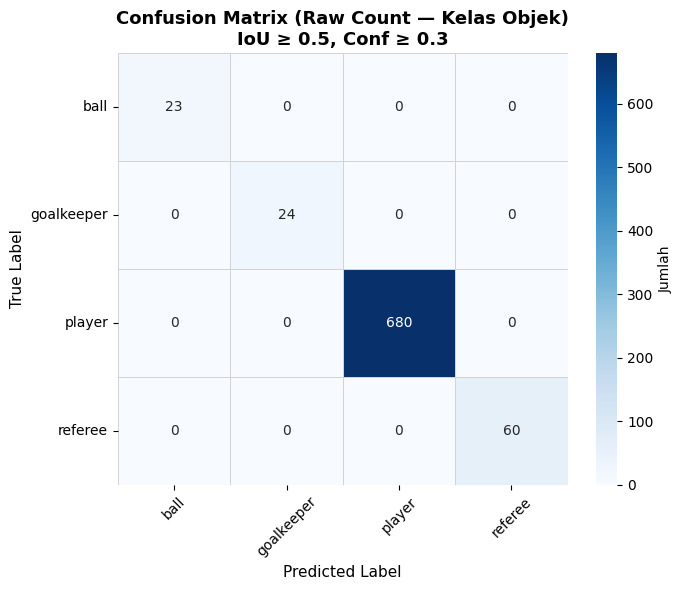

In [253]:
# ============================================================
# PLOT 1: Confusion Matrix TANPA background (hanya kelas objek)
# Seperti yang sebelumnya — untuk melihat misclassification
# ============================================================
cm_obj = cm_full[:num_classes, :num_classes]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_obj,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    linewidths=0.5, linecolor='lightgray',
    cbar_kws={'label': 'Jumlah'}
)
ax.set_title(
    f'Confusion Matrix (Raw Count — Kelas Objek)\nIoU ≥ {IOU_THRESHOLD}, Conf ≥ {CONF_THRESHOLD}',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

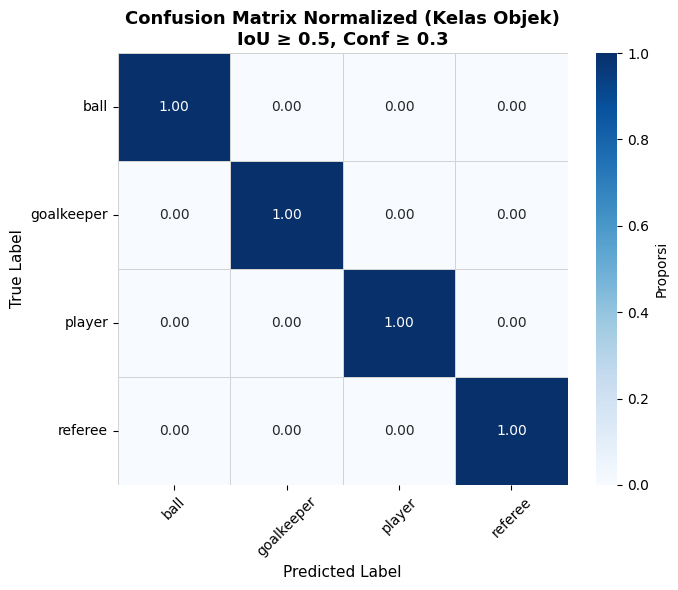

In [254]:
# ============================================================
# PLOT 2: Normalized (kelas objek saja)
# ============================================================
cm_obj_float = cm_obj.astype('float')
row_sums = cm_obj_float.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_obj_norm = cm_obj_float / row_sums

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_obj_norm,
    annot=True, fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    vmin=0, vmax=1,
    linewidths=0.5, linecolor='lightgray',
    cbar_kws={'label': 'Proporsi'}
)
ax.set_title(
    f'Confusion Matrix Normalized (Kelas Objek)\nIoU ≥ {IOU_THRESHOLD}, Conf ≥ {CONF_THRESHOLD}',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

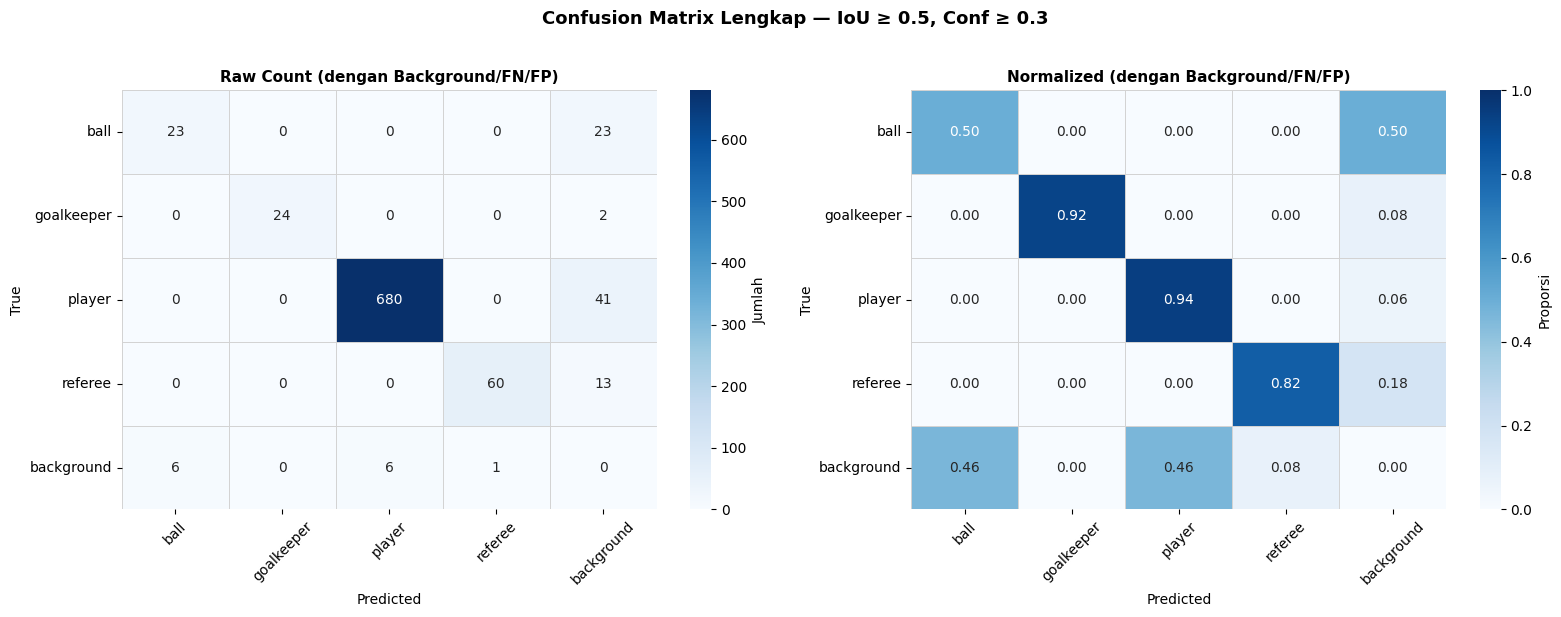

In [255]:
# ============================================================
# PLOT 3: Confusion Matrix LENGKAP dengan background
# Seperti gaya YOLO — menampilkan FN dan FP
# ============================================================
cm_full_float = cm_full.astype('float')
row_sums_full = cm_full_float.sum(axis=1, keepdims=True)
row_sums_full[row_sums_full == 0] = 1
cm_full_norm  = cm_full_float / row_sums_full

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kiri: Raw
sns.heatmap(
    cm_full,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=labels_full,
    yticklabels=labels_full,
    ax=axes[0],
    linewidths=0.5, linecolor='lightgray',
    cbar_kws={'label': 'Jumlah'}
)
axes[0].set_title('Raw Count (dengan Background/FN/FP)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=10)
axes[0].set_ylabel('True', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Kanan: Normalized
sns.heatmap(
    cm_full_norm,
    annot=True, fmt='.2f',
    cmap='Blues',
    xticklabels=labels_full,
    yticklabels=labels_full,
    ax=axes[1],
    vmin=0, vmax=1,
    linewidths=0.5, linecolor='lightgray',
    cbar_kws={'label': 'Proporsi'}
)
axes[1].set_title('Normalized (dengan Background/FN/FP)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=10)
axes[1].set_ylabel('True', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

fig.suptitle(
    f'Confusion Matrix Lengkap — IoU ≥ {IOU_THRESHOLD}, Conf ≥ {CONF_THRESHOLD}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

In [256]:
# ============================================================
# Tabel Ringkasan
# ============================================================
print(f"\n{'='*58}")
print(f"  Ringkasan per Kelas  (IoU≥{IOU_THRESHOLD}, Conf≥{CONF_THRESHOLD})")
print(f"{'='*58}")
print(f"{'Kelas':<15} {'TP':>5} {'FP':>6} {'FN':>6}  {'Precision':>10}  {'Recall':>8}")
print(f"{'-'*58}")
for i, name in enumerate(class_names):
    tp     = int(cm_full[i, i])
    fp     = int(cm_full[BG, i])      # baris background, kolom kelas i
    fn     = int(cm_full[i, BG])      # baris kelas i, kolom background
    prec   = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    print(f"{name:<15} {tp:>5} {fp:>6} {fn:>6}  {prec:>10.4f}  {recall:>8.4f}")
print(f"{'='*58}")


  Ringkasan per Kelas  (IoU≥0.5, Conf≥0.3)
Kelas              TP     FP     FN   Precision    Recall
----------------------------------------------------------
ball               23      6     23      0.7931    0.5000
goalkeeper         24      0      2      1.0000    0.9231
player            680      6     41      0.9913    0.9431
referee            60      1     13      0.9836    0.8219


*Evaluasi Model Deteksi Objek — Confusion Matrix Analysis*

**Konfigurasi:** IoU ≥ 0.5, Confidence ≥ 0.3, NMS IoU = 0.5  
**Kelas:** `ball`, `goalkeeper`, `player`, `referee`

---

#### Cara Membaca Confusion Matrix

Confusion matrix adalah tabel yang merangkum performa klasifikasi model. Setiap **baris** merepresentasikan **True Label** (kelas sebenarnya), dan setiap **kolom** merepresentasikan **Predicted Label** (kelas yang diprediksi model).

| Istilah | Definisi |
|--------|----------|
| **TP (True Positive)** | Diagonal utama — objek kelas X diprediksi benar sebagai kelas X |
| **FP (False Positive)** | Kolom non-diagonal — model memprediksi kelas X, padahal bukan kelas X |
| **FN (False Negative)** | Baris non-diagonal — objek kelas X tidak terdeteksi / salah diklasifikasi |

##### Formula Metrik
$$\text{Precision} = \frac{TP}{TP + FP}$$  
$$\text{Recall} = \frac{TP}{TP + FN}$$

> **Precision** mengukur seberapa akurat prediksi model (dari semua yang diprediksi sebagai kelas X, berapa yang benar).  
> **Recall** mengukur seberapa lengkap model mendeteksi (dari semua objek kelas X yang ada, berapa yang berhasil ditemukan).

---

#### Plot 1 — Confusion Matrix Raw Count (Kelas Objek)

> **File:** `cm_obj = cm_full[:num_classes, :num_classes]`

Plot ini menampilkan **jumlah absolut** prediksi untuk 4 kelas objek saja (`ball`, `goalkeeper`, `player`, `referee`), **tanpa memperhitungkan background/FP/FN**.

##### Cara Baca

- Nilai pada **diagonal utama** (kiri-atas ke kanan-bawah) = jumlah prediksi **benar (TP)**.
- Nilai **di luar diagonal** = jumlah prediksi **salah (misclassification)** antar kelas.
- Nilai di luar diagonal yang besar → model sering **mengacaukan satu kelas dengan kelas lain**.

##### Hasil

| True \ Predicted | ball | goalkeeper | player | referee |
|-----------------|------|------------|--------|---------|
| **ball**        | **23** | 0 | 0 | 0 |
| **goalkeeper**  | 0 | **24** | 0 | 0 |
| **player**      | 0 | 0 | **680** | 0 |
| **referee**     | 0 | 0 | 0 | **60** |

##### Interpretasi

- Seluruh nilai di luar diagonal = **0**, artinya **tidak ada misclassification antar kelas**.
- Model mampu membedakan keempat kelas dengan sempurna *di antara objek yang berhasil di-match*.
- Jumlah kelas `player` jauh lebih besar (680) karena secara natural pemain lebih banyak dalam pertandingan sepak bola.

---

#### Plot 2 — Confusion Matrix Normalized (Kelas Objek)

> **Normalisasi:** tiap baris dibagi total ground truth kelas tersebut → menunjukkan **proporsi (0.0 – 1.0)**

Plot ini adalah versi **ternormalisasi per baris** dari Plot 1. Berguna untuk membandingkan performa antar kelas meskipun jumlah sampelnya tidak seimbang.

##### Cara Baca

- Nilai diagonal = **Recall per kelas** (proporsi objek yang terdeteksi benar).
- Nilai `1.00` pada diagonal → 100% objek kelas tersebut diprediksi dengan benar.
- Nilai `0.00` di luar diagonal → tidak ada objek yang salah diklasifikasikan ke kelas lain.

##### Hasil

| True \ Predicted | ball | goalkeeper | player | referee |
|-----------------|------|------------|--------|---------|
| **ball**        | **1.00** | 0.00 | 0.00 | 0.00 |
| **goalkeeper**  | 0.00 | **1.00** | 0.00 | 0.00 |
| **player**      | 0.00 | 0.00 | **1.00** | 0.00 |
| **referee**     | 0.00 | 0.00 | 0.00 | **1.00** |

##### Interpretasi

- Semua diagonal bernilai **1.00** → di antara objek yang berhasil di-match dengan IoU ≥ 0.5, model **tidak pernah salah mengklasifikasikan** kelas.
- Plot ini terlihat "sempurna" karena FN (missed detection) tidak masuk ke matriks ini — hanya objek yang sudah ter-match yang dihitung.
- Untuk melihat gambaran lebih lengkap termasuk objek yang tidak terdeteksi, perlu melihat **Plot 3**.

---

#### Plot 3 — Confusion Matrix Lengkap dengan Background (FN & FP)

> **Dimensi:** `(num_classes + 1) × (num_classes + 1)` → menambahkan baris & kolom `background`

Ini adalah confusion matrix **bergaya YOLO** yang paling informatif karena memperhitungkan:

| Kolom `background` | = **FN** (False Negative) — objek ground truth tidak terdeteksi oleh model |
|--------------------|-------------------------------------------------------------------------|
| **Baris `background`** | = **FP** (False Positive) — model mendeteksi sesuatu yang bukan objek nyata |

##### Sub-plot Kiri: Raw Count

| True \ Predicted | ball | goalkeeper | player | referee | background (FN) |
|-----------------|------|------------|--------|---------|-----------------|
| **ball**        | 23 | 0 | 0 | 0 | **23** |
| **goalkeeper**  | 0 | 24 | 0 | 0 | **2** |
| **player**      | 0 | 0 | 680 | 0 | **41** |
| **referee**     | 0 | 0 | 0 | 60 | **13** |
| **background (FP)** | **6** | 0 | **6** | **1** | — |

##### Sub-plot Kanan: Normalized

| True \ Predicted | ball | goalkeeper | player | referee | background |
|-----------------|------|------------|--------|---------|------------|
| **ball**        | **0.50** | 0.00 | 0.00 | 0.00 | 0.50 |
| **goalkeeper**  | 0.00 | **0.92** | 0.00 | 0.00 | 0.08 |
| **player**      | 0.00 | 0.00 | **0.94** | 0.00 | 0.06 |
| **referee**     | 0.00 | 0.00 | 0.00 | **0.82** | 0.18 |
| **background**  | 0.46 | 0.00 | 0.46 | 0.08 | 0.00 |

##### Interpretasi

| Kelas | Recall Nyata | Analisis |
|-------|-------------|---------|
| **ball** | 0.50 | ⚠️ Hanya 50% bola terdeteksi — 23 dari 46 bola **tidak terdeteksi (FN)**. Bola kecil dan sering teroklusi, sehingga sulit dideteksi. |
| **goalkeeper** | 0.92 | ✅ Sangat baik — hanya 2 goalkeeper yang terlewat. |
| **player** | 0.94 | ✅ Sangat baik — dari 721 player, hanya 41 yang tidak terdeteksi. |
| **referee** | 0.82 | 🔶 Cukup baik — 13 wasit tidak terdeteksi, kemungkinan karena jumlah sampel lebih sedikit. |
| **background FP** | — | Model menghasilkan 13 false positive: 6 diprediksi sebagai `ball`, 6 sebagai `player`, 1 sebagai `referee`. |

---

#### Tabel Ringkasan Per Kelas
```
==========================================================
  Ringkasan per Kelas  (IoU≥0.5, Conf≥0.3)
==========================================================
Kelas              TP     FP     FN   Precision    Recall
----------------------------------------------------------
ball               23      6     23      0.7931    0.5000
goalkeeper         24      0      2      1.0000    0.9231
player            680      6     41      0.9913    0.9431
referee            60      1     13      0.9836    0.8219
==========================================================
```

| Kelas | TP | FP | FN | Precision | Recall | Analisis |
|-------|----|----|----|-----------|--------|---------|
| **ball** | 23 | 6 | 23 | 0.7931 | **0.5000** | ⚠️ Recall terendah. Model hanya menemukan setengah dari semua bola. FP=6 (ada false alarm). Perlu augmentasi data / tuning threshold. |
| **goalkeeper** | 24 | 0 | 2 | **1.0000** | 0.9231 | ✅ Precision sempurna — tidak ada satupun false positive. Hanya 2 goalkeeper yang terlewat. |
| **player** | 680 | 6 | 41 | 0.9913 | 0.9431 | ✅ Performa terbaik secara volume. Precision dan recall sama-sama tinggi. |
| **referee** | 60 | 1 | 13 | 0.9836 | 0.8219 | 🔶 Precision tinggi, namun recall 82% — 13 wasit tidak terdeteksi, mungkin akibat keterbatasan data. |

##### Kesimpulan

1. **Tidak ada misclassification antar kelas** — model tidak pernah mengacaukan `ball` dengan `player`, dll.
2. **Masalah utama ada pada deteksi `ball`** — recall hanya 50%, yang mengindikasikan banyak objek bola tidak ter-match dengan threshold IoU ≥ 0.5 (bola kecil → area overlap kecil).
3. **`goalkeeper` dan `player` memiliki performa sangat baik**, khususnya precision yang mendekati 1.0.
4. **`referee` perlu perhatian** pada recall — penambahan data latih untuk kelas ini dapat meningkatkan performa.
5. **False Positive (background row)** berjumlah sedikit (13 total), menunjukkan model tidak terlalu "trigger-happy" dalam membuat prediksi palsu.

## IoU Distribution (Error Analysis)

Hitung IoU: 100%|██████████| 50/50 [00:25<00:00,  1.98it/s]


Total matched pairs : 793
TP (IoU≥0.5, kelas benar): 787
Salah kelas (IoU≥0.5)     : 0
Di bawah threshold (IoU<0.5): 6


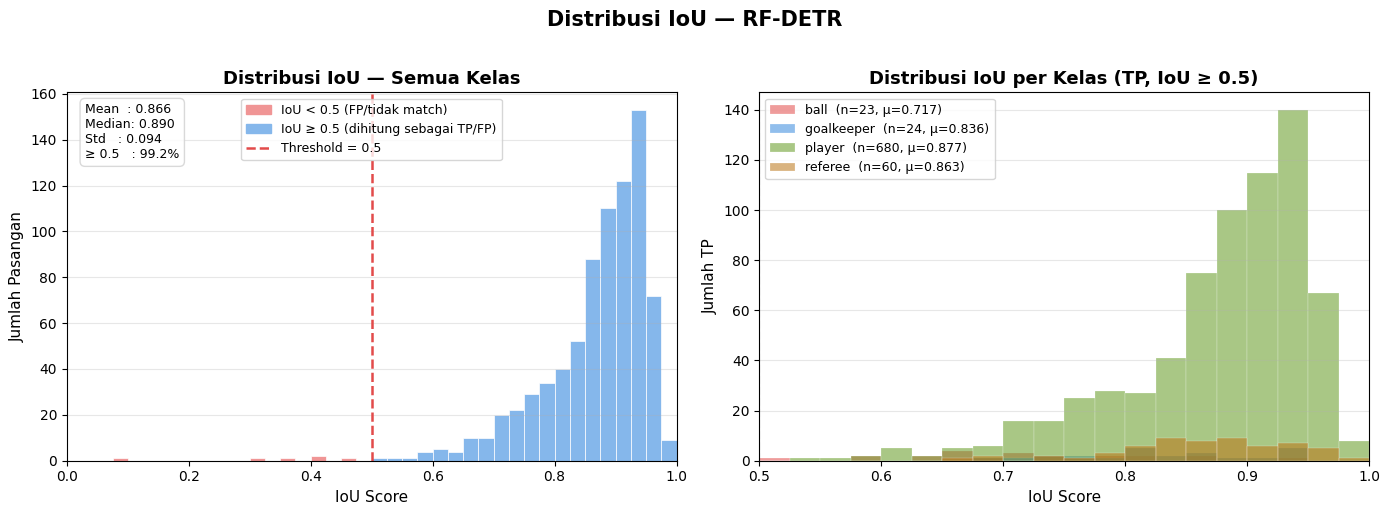

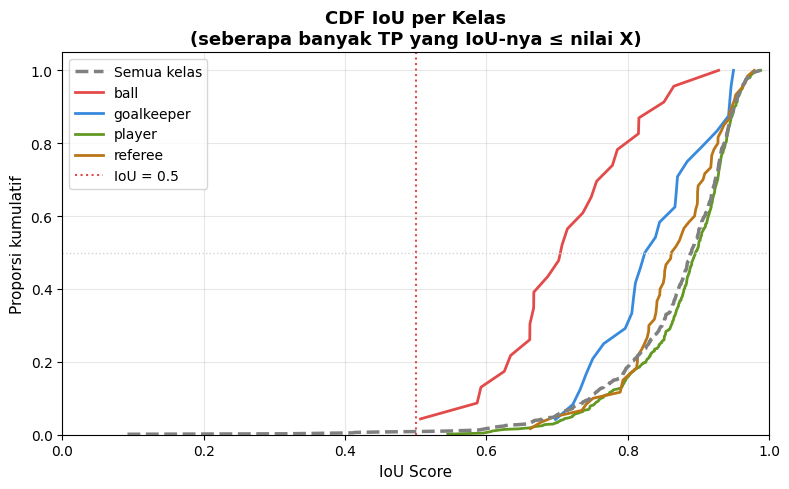

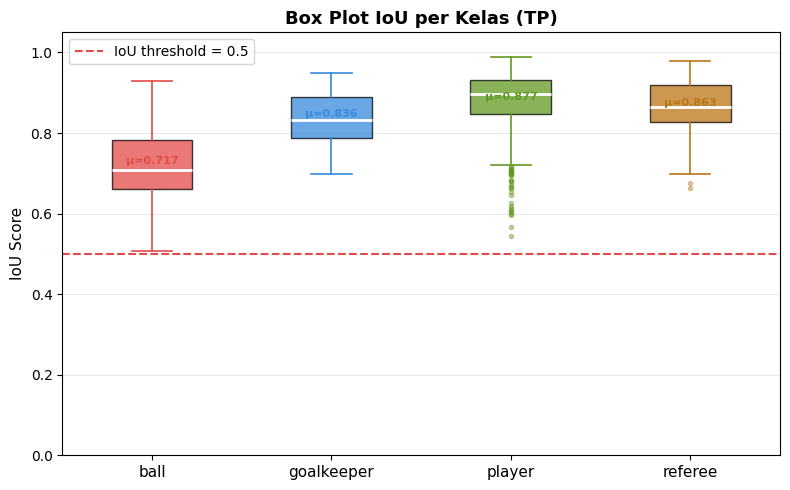


  Ringkasan IoU Distribution per Kelas  (TP, IoU ≥ 0.5)
Kelas               N     Mean    Median     Std    ≥0.75    ≥0.90
-----------------------------------------------------------------
  ball             23   0.7172    0.7073  0.0977    34.8%     4.3%
  goalkeeper       24   0.8361    0.8318  0.0750    83.3%    25.0%
  player          680   0.8772    0.8965  0.0765    92.1%    48.5%
  referee          60   0.8633    0.8651  0.0716    91.7%    31.7%
-----------------------------------------------------------------
  Semua kelas     787   0.8702    0.8906  0.0816    90.1%    45.2%


In [257]:
# ============================================================
# KONFIGURASI
# ============================================================
# class_names   = ['ball', 'goalkeeper', 'player', 'referee']
num_classes   = len(class_names)
CONF_THRESHOLD = 0.3
IOU_THRESHOLD  = 0.5
colors         = ['#E24B4A', '#378ADD', '#639922', '#BA7517']

def gt_to_idx(coco_id):
    return int(coco_id) - 1

def pred_to_idx(raw_id):
    return int(int(raw_id) % 5) - 1

def is_valid_idx(idx):
    return 0 <= idx <= (num_classes - 1)

# ============================================================
# KUMPULKAN IoU DARI SEMUA MATCHED PAIR
# ============================================================
iou_all         = []              # semua IoU (seluruh kelas)
iou_per_class   = [[] for _ in range(num_classes)]   # IoU per kelas
iou_tp          = []              # IoU hanya TP (kelas sama)
iou_wrong_class = []              # IoU match tapi kelas salah

for path, image_np, gt in tqdm(ds, desc="Hitung IoU"):
    image = Image.open(path)
    pred  = model.predict(image, threshold=CONF_THRESHOLD)

    # Konversi GT
    if len(gt) > 0:
        gt_idx_list = [gt_to_idx(c) for c in gt.class_id]
        gt_valid    = np.array([is_valid_idx(i) for i in gt_idx_list])
        gt = gt[gt_valid]
        if len(gt) > 0:
            gt.class_id = np.array([i for i, v in zip(gt_idx_list, gt_valid) if v])

    # Konversi Pred + NMS
    if len(pred) > 0:
        pred_idx_list = [pred_to_idx(c) for c in pred.class_id]
        pred_valid    = np.array([is_valid_idx(i) for i in pred_idx_list])
        pred = pred[pred_valid]
        if len(pred) > 0:
            pred.class_id = np.array([i for i, v in zip(pred_idx_list, pred_valid) if v])
            pred = pred.with_nms(threshold=0.5, class_agnostic=True)

    if len(gt) == 0 or len(pred) == 0:
        continue

    gt_classes   = gt.class_id
    pred_classes = pred.class_id
    gt_boxes     = gt.xyxy
    pred_boxes   = pred.xyxy

    # Hitung IoU matrix
    iou_matrix = sv.box_iou_batch(pred_boxes, gt_boxes)  # (n_pred, n_gt)

    matched_gt   = np.zeros(len(gt_classes),   dtype=bool)
    matched_pred = np.zeros(len(pred_classes), dtype=bool)

    # Greedy matching dari IoU tertinggi
    pairs = [
        (iou_matrix[pi, gi], pi, gi)
        for pi in range(len(pred_classes))
        for gi in range(len(gt_classes))
        if iou_matrix[pi, gi] > 0
    ]
    pairs.sort(key=lambda x: -x[0])

    for iou_val, pi, gi in pairs:
        if matched_pred[pi] or matched_gt[gi]:
            continue

        matched_pred[pi] = True
        matched_gt[gi]   = True

        true_cls = gt_classes[gi]
        pred_cls = pred_classes[pi]

        iou_all.append(iou_val)

        if iou_val >= IOU_THRESHOLD:
            if true_cls == pred_cls:
                # TP: kelas benar
                iou_tp.append(iou_val)
                iou_per_class[true_cls].append(iou_val)
            else:
                # Match tapi kelas salah
                iou_wrong_class.append(iou_val)

iou_all         = np.array(iou_all)
iou_tp          = np.array(iou_tp)
iou_wrong_class = np.array(iou_wrong_class)

print(f"Total matched pairs : {len(iou_all)}")
print(f"TP (IoU≥{IOU_THRESHOLD}, kelas benar): {len(iou_tp)}")
print(f"Salah kelas (IoU≥{IOU_THRESHOLD})     : {len(iou_wrong_class)}")
print(f"Di bawah threshold (IoU<{IOU_THRESHOLD}): {(iou_all < IOU_THRESHOLD).sum()}")

# ============================================================
# PLOT 1: Distribusi IoU Keseluruhan
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.linspace(0, 1, 41)   # 40 bin dari 0 sampai 1

n, _, patches = ax.hist(iou_all, bins=bins, edgecolor='white', linewidth=0.5)

# Warnai bin: merah=di bawah threshold, biru=di atas
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge < IOU_THRESHOLD:
        patch.set_facecolor('#F09595')   # merah muda
    else:
        patch.set_facecolor('#85B7EB')   # biru

# Garis threshold
ax.axvline(IOU_THRESHOLD, color='#E24B4A', linestyle='--', linewidth=1.8,
           label=f'Threshold IoU = {IOU_THRESHOLD}')

ax.set_title('Distribusi IoU — Semua Kelas', fontsize=13, fontweight='bold')
ax.set_xlabel('IoU Score', fontsize=11)
ax.set_ylabel('Jumlah Pasangan', fontsize=11)
ax.set_xlim(0, 1)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=10)

# Statistik di dalam plot
stats_text = (
    f"Mean  : {iou_all.mean():.3f}\n"
    f"Median: {np.median(iou_all):.3f}\n"
    f"Std   : {iou_all.std():.3f}\n"
    f"≥ {IOU_THRESHOLD}   : {(iou_all >= IOU_THRESHOLD).mean()*100:.1f}%"
)
ax.text(0.03, 0.97, stats_text,
        transform=ax.transAxes, fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='lightgray', alpha=0.85))

# Patch legend warna
patch_below = mpatches.Patch(color='#F09595', label=f'IoU < {IOU_THRESHOLD} (FP/tidak match)')
patch_above = mpatches.Patch(color='#85B7EB', label=f'IoU ≥ {IOU_THRESHOLD} (dihitung sebagai TP/FP)')
ax.legend(handles=[patch_below, patch_above,
                   plt.Line2D([0], [0], color='#E24B4A', linestyle='--', linewidth=1.8,
                              label=f'Threshold = {IOU_THRESHOLD}')],
          fontsize=9, loc='upper center')

# ============================================================
# PLOT 2: Distribusi IoU per Kelas (hanya TP)
# ============================================================
ax2 = axes[1]

for i, name in enumerate(class_names):
    if len(iou_per_class[i]) == 0:
        continue
    iou_arr = np.array(iou_per_class[i])
    ax2.hist(iou_arr, bins=bins, alpha=0.55, color=colors[i], edgecolor='white',
             linewidth=0.3, label=f'{name}  (n={len(iou_arr)}, μ={iou_arr.mean():.3f})')

ax2.axvline(IOU_THRESHOLD, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.set_title(f'Distribusi IoU per Kelas (TP, IoU ≥ {IOU_THRESHOLD})',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('IoU Score', fontsize=11)
ax2.set_ylabel('Jumlah TP', fontsize=11)
ax2.set_xlim(IOU_THRESHOLD, 1)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(fontsize=9)

fig.suptitle('Distribusi IoU — RF-DETR', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: CDF (Cumulative Distribution Function) IoU per Kelas
# Menunjukkan "berapa % prediksi yang IoU-nya ≥ nilai X"
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

# CDF semua kelas
sorted_all = np.sort(iou_all)
cdf_all    = np.arange(1, len(sorted_all)+1) / len(sorted_all)
ax.plot(sorted_all, cdf_all, color='gray', linewidth=2.5,
        linestyle='--', label='Semua kelas', zorder=5)

# CDF per kelas
for i, name in enumerate(class_names):
    if len(iou_per_class[i]) == 0:
        continue
    sorted_iou = np.sort(iou_per_class[i])
    cdf        = np.arange(1, len(sorted_iou)+1) / len(sorted_iou)
    ax.plot(sorted_iou, cdf, color=colors[i], linewidth=2, label=name)

ax.axvline(IOU_THRESHOLD, color='#E24B4A', linestyle=':', linewidth=1.5,
           label=f'IoU = {IOU_THRESHOLD}')
ax.axhline(0.5, color='lightgray', linestyle=':', linewidth=1)

ax.set_title('CDF IoU per Kelas\n(seberapa banyak TP yang IoU-nya ≤ nilai X)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('IoU Score', fontsize=11)
ax.set_ylabel('Proporsi kumulatif', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 4: Box Plot IoU per Kelas
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

data_bp    = [iou_per_class[i] for i in range(num_classes) if len(iou_per_class[i]) > 0]
labels_bp  = [class_names[i]  for i in range(num_classes) if len(iou_per_class[i]) > 0]
colors_bp  = [colors[i]        for i in range(num_classes) if len(iou_per_class[i]) > 0]

bp = ax.boxplot(data_bp, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))

for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for whisker, cap, color in zip(
        zip(bp['whiskers'][::2], bp['whiskers'][1::2]),
        zip(bp['caps'][::2],     bp['caps'][1::2]),
        colors_bp):
    for elem in whisker + cap:
        elem.set_color(color)

for flier, color in zip(bp['fliers'], colors_bp):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

ax.axhline(IOU_THRESHOLD, color='#E24B4A', linestyle='--', linewidth=1.5,
           label=f'IoU threshold = {IOU_THRESHOLD}', zorder=0)

ax.set_xticks(range(1, len(labels_bp)+1))
ax.set_xticklabels(labels_bp, fontsize=11)
ax.set_title('Box Plot IoU per Kelas (TP)', fontsize=13, fontweight='bold')
ax.set_ylabel('IoU Score', fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=10)

# Tambahkan mean & median label
for i, (data, color) in enumerate(zip(data_bp, colors_bp), start=1):
    arr = np.array(data)
    ax.text(i, arr.mean(), f'μ={arr.mean():.3f}',
            ha='center', va='bottom', fontsize=8,
            color=color, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# TABEL RINGKASAN
# ============================================================
print(f"\n{'='*65}")
print(f"  Ringkasan IoU Distribution per Kelas  (TP, IoU ≥ {IOU_THRESHOLD})")
print(f"{'='*65}")
print(f"{'Kelas':<15} {'N':>5}  {'Mean':>7}  {'Median':>8}  {'Std':>6}  {'≥0.75':>7}  {'≥0.90':>7}")
print(f"{'-'*65}")
for i, name in enumerate(class_names):
    arr = np.array(iou_per_class[i])
    if len(arr) == 0:
        print(f"  {name:<13} {'0':>5}  {'N/A':>7}")
        continue
    n        = len(arr)
    mean_v   = arr.mean()
    median_v = np.median(arr)
    std_v    = arr.std()
    p75      = (arr >= 0.75).mean() * 100
    p90      = (arr >= 0.90).mean() * 100
    print(f"  {name:<13} {n:>5}  {mean_v:>7.4f}  {median_v:>8.4f}  {std_v:>6.4f}  {p75:>6.1f}%  {p90:>6.1f}%")

print(f"{'-'*65}")
all_tp = np.concatenate([iou_per_class[i] for i in range(num_classes) if len(iou_per_class[i])>0])
print(f"  {'Semua kelas':<13} {len(all_tp):>5}  {all_tp.mean():>7.4f}  {np.median(all_tp):>8.4f}  "
      f"{all_tp.std():>6.4f}  {(all_tp>=0.75).mean()*100:>6.1f}%  {(all_tp>=0.90).mean()*100:>6.1f}%")
print(f"{'='*65}")

*📦 IoU Distribution*

**IoU (Intersection over Union)** mengukur seberapa besar overlap antara
bounding box prediksi model dengan bounding box asli (Ground Truth).
Nilainya antara 0.0 (tidak overlap sama sekali) hingga 1.0 (sempurna).

$$\text{IoU} = \frac{\text{Area Irisan}}{\text{Area Gabungan}}$$

##### Empat visualisasi yang dibuat

| Plot | Isi | Kegunaan |
|------|-----|---------|
| **Histogram keseluruhan** | Distribusi semua IoU, merah = di bawah threshold | Lihat seberapa banyak prediksi yang "cukup overlap" |
| **Histogram per kelas** | Distribusi IoU khusus TP per kelas | Bandingkan kualitas lokalisasi antar kelas |
| **CDF per kelas** | Kurva kumulatif IoU | Lihat "berapa % TP yang IoU-nya ≥ nilai X" |
| **Box plot per kelas** | Median, IQR, outlier per kelas | Ringkasan statistik IoU yang mudah dibandingkan |

##### Cara membaca hasilnya

- **Mean IoU tinggi (mendekati 1.0)** = model sangat presisi dalam melokalisasi objek
- **Banyak nilai mendekati 0.5** = model pas-pasan, box-nya tidak terlalu tepat
- **Kolom "≥0.75" dan "≥0.90"** di tabel = persentase TP yang memenuhi threshold lebih ketat
  (ini adalah basis dari mAP@75 dan mAP@90)
- **Kelas dengan IoU rendah** biasanya objek kecil (bola) atau objek yang sering occluded

=======================================================================================================

*Analisis Distribusi IoU — RF-DETR*

**Konfigurasi:** IoU Threshold ≥ 0.5, Confidence ≥ 0.3  
**Kelas:** `ball`, `goalkeeper`, `player`, `referee`

---

#### Apa itu IoU?

**IoU (Intersection over Union)** adalah metrik yang mengukur seberapa besar overlap antara bounding box prediksi dan bounding box ground truth.

$$\text{IoU} = \frac{\text{Area Irisan (Intersection)}}{\text{Area Gabungan (Union)}}$$

| Rentang IoU | Interpretasi |
|------------|-------------|
| **IoU = 1.0** | Bounding box prediksi dan ground truth **identik sempurna** |
| **IoU ≥ 0.9** | Lokalisasi **sangat presisi** |
| **0.75 ≤ IoU < 0.9** | Lokalisasi **baik** |
| **0.5 ≤ IoU < 0.75** | Lokalisasi **cukup** — masih dihitung sebagai TP |
| **IoU < 0.5** | Prediksi dianggap **gagal match** → FP atau tidak dihitung |

> IoU tinggi berarti model tidak hanya benar mengklasifikasikan, tetapi juga **akurat menentukan posisi dan ukuran** bounding box.

---

#### Output Teks Awal
```
Total matched pairs : 793
TP (IoU≥0.5, kelas benar): 787
Salah kelas (IoU≥0.5)    : 0
Di bawah threshold (IoU<0.5): 6
```

| Metrik | Nilai | Interpretasi |
|--------|-------|-------------|
| **Total matched pairs** | 793 | Jumlah total pasangan (pred–GT) yang berhasil di-match secara geometris (IoU > 0) menggunakan greedy matching |
| **TP (kelas benar, IoU≥0.5)** | 787 | Prediksi yang lokasi-nya tepat (IoU≥0.5) **dan** kelasnya juga benar → True Positive sesungguhnya |
| **Salah kelas (IoU≥0.5)** | 0 | Tidak ada satupun prediksi yang box-nya overlap cukup tapi kelasnya salah — menunjukkan **tidak ada misclassification** |
| **Di bawah threshold (IoU<0.5)** | 6 | 6 pasangan yang box-nya overlap tapi kurang dari 0.5 → dianggap tidak valid, diperlakukan sebagai FP |

**Kesimpulan awal:** Dari 793 match, 99.2% memenuhi threshold IoU, dan **0% misclassification** — model sangat baik dalam membedakan kelas.

---

#### Plot 1 — Distribusi IoU Keseluruhan (Kiri) & Per Kelas (Kanan)

##### Sub-plot Kiri: Distribusi IoU Semua Kelas

Plot histogram ini menampilkan **distribusi nilai IoU dari seluruh matched pair** (787 TP + 6 di bawah threshold).

**Cara membaca:**
- Sumbu X = nilai IoU (0 sampai 1)
- Sumbu Y = jumlah pasangan prediksi–GT di rentang IoU tersebut
- **Bar merah muda** = pasangan dengan IoU < 0.5 → dianggap FP / tidak valid
- **Bar biru** = pasangan dengan IoU ≥ 0.5 → dihitung sebagai TP atau FP
- **Garis putus-putus merah** = threshold IoU = 0.5

**Statistik yang tertera:**
| Statistik | Nilai | Interpretasi |
|-----------|-------|-------------|
| **Mean** | 0.866 | Rata-rata IoU dari semua pasangan — sangat tinggi |
| **Median** | 0.890 | 50% pasangan memiliki IoU ≥ 0.890 |
| **Std** | 0.094 | Variasi IoU relatif kecil → prediksi konsisten |
| **≥ 0.5** | 99.2% | Hanya 0.8% pasangan (6 dari 793) yang tidak memenuhi threshold |

**Interpretasi bentuk histogram:** Distribusi **miring ke kiri (left-skewed)** dengan puncak di rentang 0.90–0.95. Ini berarti mayoritas prediksi memiliki IoU yang sangat tinggi — model tidak hanya benar kelasnya, tetapi juga sangat presisi dalam menentukan lokasi bounding box.

---

##### Sub-plot Kanan: Distribusi IoU per Kelas (Hanya TP)

Plot ini memperlihatkan distribusi IoU **dipisah per kelas**, hanya untuk TP (IoU ≥ 0.5, kelas benar).

**Cara membaca:**
- Setiap warna mewakili satu kelas
- Label legenda menampilkan: nama kelas, `n` = jumlah TP, `μ` = rata-rata IoU kelas tersebut
- Sumbu X dimulai dari 0.5 (threshold) karena hanya TP yang ditampilkan

**Perbandingan antar kelas:**
| Kelas | n | μ IoU | Interpretasi |
|-------|---|-------|-------------|
| **ball** | 23 | 0.717 | IoU terendah — distribusi lebih menyebar ke kiri, bola sulit dilokalisasi akurat karena ukurannya kecil |
| **goalkeeper** | 24 | 0.836 | Lokalisasi baik, distribusi terkonsentrasi di 0.75–0.95 |
| **player** | 680 | 0.877 | IoU tinggi dengan jumlah sampel terbesar — model paling terlatih untuk kelas ini |
| **referee** | 60 | 0.863 | Lokalisasi baik, mirip dengan goalkeeper |

---

#### Plot 2 — CDF IoU per Kelas

**CDF (Cumulative Distribution Function)** menunjukkan: *"Berapa proporsi TP yang memiliki IoU ≤ nilai X?"*

**Cara membaca:**
- Sumbu X = nilai IoU
- Sumbu Y = proporsi kumulatif (0.0 = tidak ada, 1.0 = semua)
- **Kurva yang lebih ke kanan** = distribusi IoU lebih tinggi = lokalisasi lebih presisi
- **Garis putus-putus merah** = IoU threshold = 0.5
- Di titik IoU = 0.5, semua kurva TP mulai dari 0 (karena kita hanya plot TP yang sudah ≥ 0.5)

**Cara membaca nilai spesifik:**
> Jika kurva `player` mencapai Y=0.5 di X=0.88, artinya **50% TP player memiliki IoU ≤ 0.88** (atau sebaliknya: 50% memiliki IoU ≥ 0.88 = median)

**Perbandingan kurva:**
| Kelas | Posisi Kurva | Interpretasi |
|-------|-------------|-------------|
| **ball** (merah) | Paling kiri | IoU paling rendah → kurva naik lebih cepat di nilai IoU rendah |
| **player** (hijau) | Paling kanan bersama referee | IoU paling tinggi → kurva naik lambat, berarti banyak TP dengan IoU tinggi |
| **goalkeeper** (biru) | Di antara ball dan player | Performa lokalisasi menengah |
| **Semua kelas** (abu-abu putus) | Rata-rata keseluruhan | Referensi agregat |

> **Interpretasi kunci:** Kurva `ball` yang paling kiri mengonfirmasi bahwa bola memiliki IoU yang lebih rendah dibanding kelas lain — bukan karena salah kelas, tetapi karena **lokalisasi bounding box-nya kurang presisi**.

---

#### Plot 3 — Box Plot IoU per Kelas

Box plot menampilkan **distribusi statistik IoU** secara ringkas untuk setiap kelas.

**Cara membaca elemen box plot:**
```
          ┌─────────────────────┐
  ───|─── │   Q1 │ Median │ Q3  │ ───|───   ○ outlier
          └─────────────────────┘
  ^                               ^
whisker bawah               whisker atas
(Q1 - 1.5×IQR)             (Q3 + 1.5×IQR)
```

| Elemen | Definisi |
|--------|----------|
| **Garis putih tengah** | Median (Q2) — nilai IoU tengah |
| **Box bawah (Q1)** | 25% data berada di bawah nilai ini |
| **Box atas (Q3)** | 75% data berada di bawah nilai ini |
| **IQR** | Q3 − Q1 = rentang tengah 50% data |
| **Whisker** | Rentang data non-outlier (hingga 1.5×IQR dari box) |
| **Titik (○)** | Outlier — nilai ekstrem di luar whisker |
| **Label μ** | Nilai mean (rata-rata) IoU kelas tersebut |

**Perbandingan antar kelas:**
| Kelas | μ IoU | Interpretasi |
|-------|-------|-------------|
| **ball** | 0.717 | ⚠️ Box paling rendah dan lebar → IoU lebih rendah dan tidak konsisten. Whisker bawah mendekati threshold 0.5, artinya ada TP dengan IoU hampir gagal match |
| **goalkeeper** | 0.836 | ✅ Box kompak di 0.75–0.90 → lokalisasi konsisten baik |
| **player** | 0.877 | ✅ Box tertinggi dengan beberapa outlier ke bawah (titik hijau) — wajar karena n=680 sangat besar |
| **referee** | 0.863 | ✅ Box sempit di 0.82–0.93 → sangat konsisten |

> **Garis putus-putus merah** (IoU = 0.5) jauh di bawah semua box, artinya seluruh kelas memiliki median dan Q1 yang jauh di atas threshold — **kualitas lokalisasi sangat baik**.

---

#### Tabel Ringkasan IoU Distribution per Kelas
```
=================================================================
  Ringkasan IoU Distribution per Kelas  (TP, IoU ≥ 0.5)
=================================================================
Kelas               N     Mean    Median     Std    ≥0.75    ≥0.90
-----------------------------------------------------------------
  ball             23   0.7172    0.7073  0.0977    34.8%     4.3%
  goalkeeper       24   0.8361    0.8318  0.0750    83.3%    25.0%
  player          680   0.8772    0.8965  0.0765    92.1%    48.5%
  referee          60   0.8633    0.8651  0.0716    91.7%    31.7%
-----------------------------------------------------------------
  Semua kelas     787   0.8702    0.8906  0.0816    90.1%    45.2%
=================================================================
```

**Penjelasan setiap kolom:**

| Kolom | Definisi | Cara Baca |
|-------|----------|-----------|
| **N** | Jumlah TP per kelas | Berapa banyak prediksi benar yang digunakan untuk menghitung statistik ini |
| **Mean** | Rata-rata IoU | Semakin mendekati 1.0, semakin akurat lokalisasi rata-rata |
| **Median** | Nilai IoU tengah | 50% TP berada di atas nilai ini; lebih robust terhadap outlier |
| **Std** | Standar deviasi IoU | Semakin kecil = semakin konsisten; Std besar berarti lokalisasi tidak stabil |
| **≥0.75** | % TP dengan IoU ≥ 0.75 | Proporsi prediksi dengan lokalisasi **baik** |
| **≥0.90** | % TP dengan IoU ≥ 0.90 | Proporsi prediksi dengan lokalisasi **sangat presisi** |

**Analisis per kelas:**

| Kelas | Analisis |
|-------|---------|
| **ball** | ⚠️ Mean (0.717) dan Median (0.707) terendah. Hanya 34.8% TP yang IoU-nya ≥ 0.75, dan hanya 4.3% yang sangat presisi (≥0.90). Std tertinggi (0.0977) → lokalisasi tidak konsisten. Bola berukuran kecil membuat overlap bounding box sangat sensitif terhadap sedikit pergeseran. |
| **goalkeeper** | ✅ Mean 0.836 dan Std rendah (0.075). 83.3% TP memiliki IoU ≥ 0.75 — lokalisasi baik dan cukup konsisten. |
| **player** | ✅ Performa terbaik dengan n terbesar. Mean 0.877, median 0.897. 92.1% TP IoU ≥ 0.75 dan hampir separuhnya (48.5%) bahkan ≥ 0.90 — lokalisasi sangat presisi. |
| **referee** | ✅ Std terkecil (0.0716) → paling konsisten. 91.7% TP memiliki IoU ≥ 0.75 meski jumlah sampel lebih sedikit. |
| **Semua kelas** | Secara keseluruhan, 90.1% dari 787 TP memiliki IoU ≥ 0.75 dan 45.2% bahkan ≥ 0.90 — menunjukkan model RF-DETR sangat presisi dalam lokalisasi. |

---

#### Kesimpulan Keseluruhan

| Aspek | Temuan |
|-------|--------|
| **Misclassification** | 0 kasus — model tidak pernah mengacaukan satu kelas dengan kelas lain |
| **Coverage (Recall IoU)** | 99.2% pasangan memenuhi threshold IoU ≥ 0.5 |
| **Kelas terbaik** | `player` — n terbesar, IoU tertinggi, paling banyak data latih |
| **Kelas paling lemah** | `ball` — IoU terendah (μ=0.717), lokalisasi kurang presisi akibat ukuran objek kecil |
| **Konsistensi lokalisasi** | Semua kelas kecuali `ball` memiliki Std < 0.08 → lokalisasi stabil |
| **Rekomendasi** | Fokus perbaikan pada kelas `ball`: augmentasi skala kecil, anchor box lebih kecil, atau peningkatan resolusi input |

# Worst FN FN Analysis

Evaluasi per gambar: 100%|██████████| 50/50 [00:24<00:00,  2.04it/s]



Selesai evaluasi 50 gambar.
Total TP=787  |  FN=79  |  FP=13
Recall keseluruhan  : 0.9088
Precision keseluruhan: 0.9837


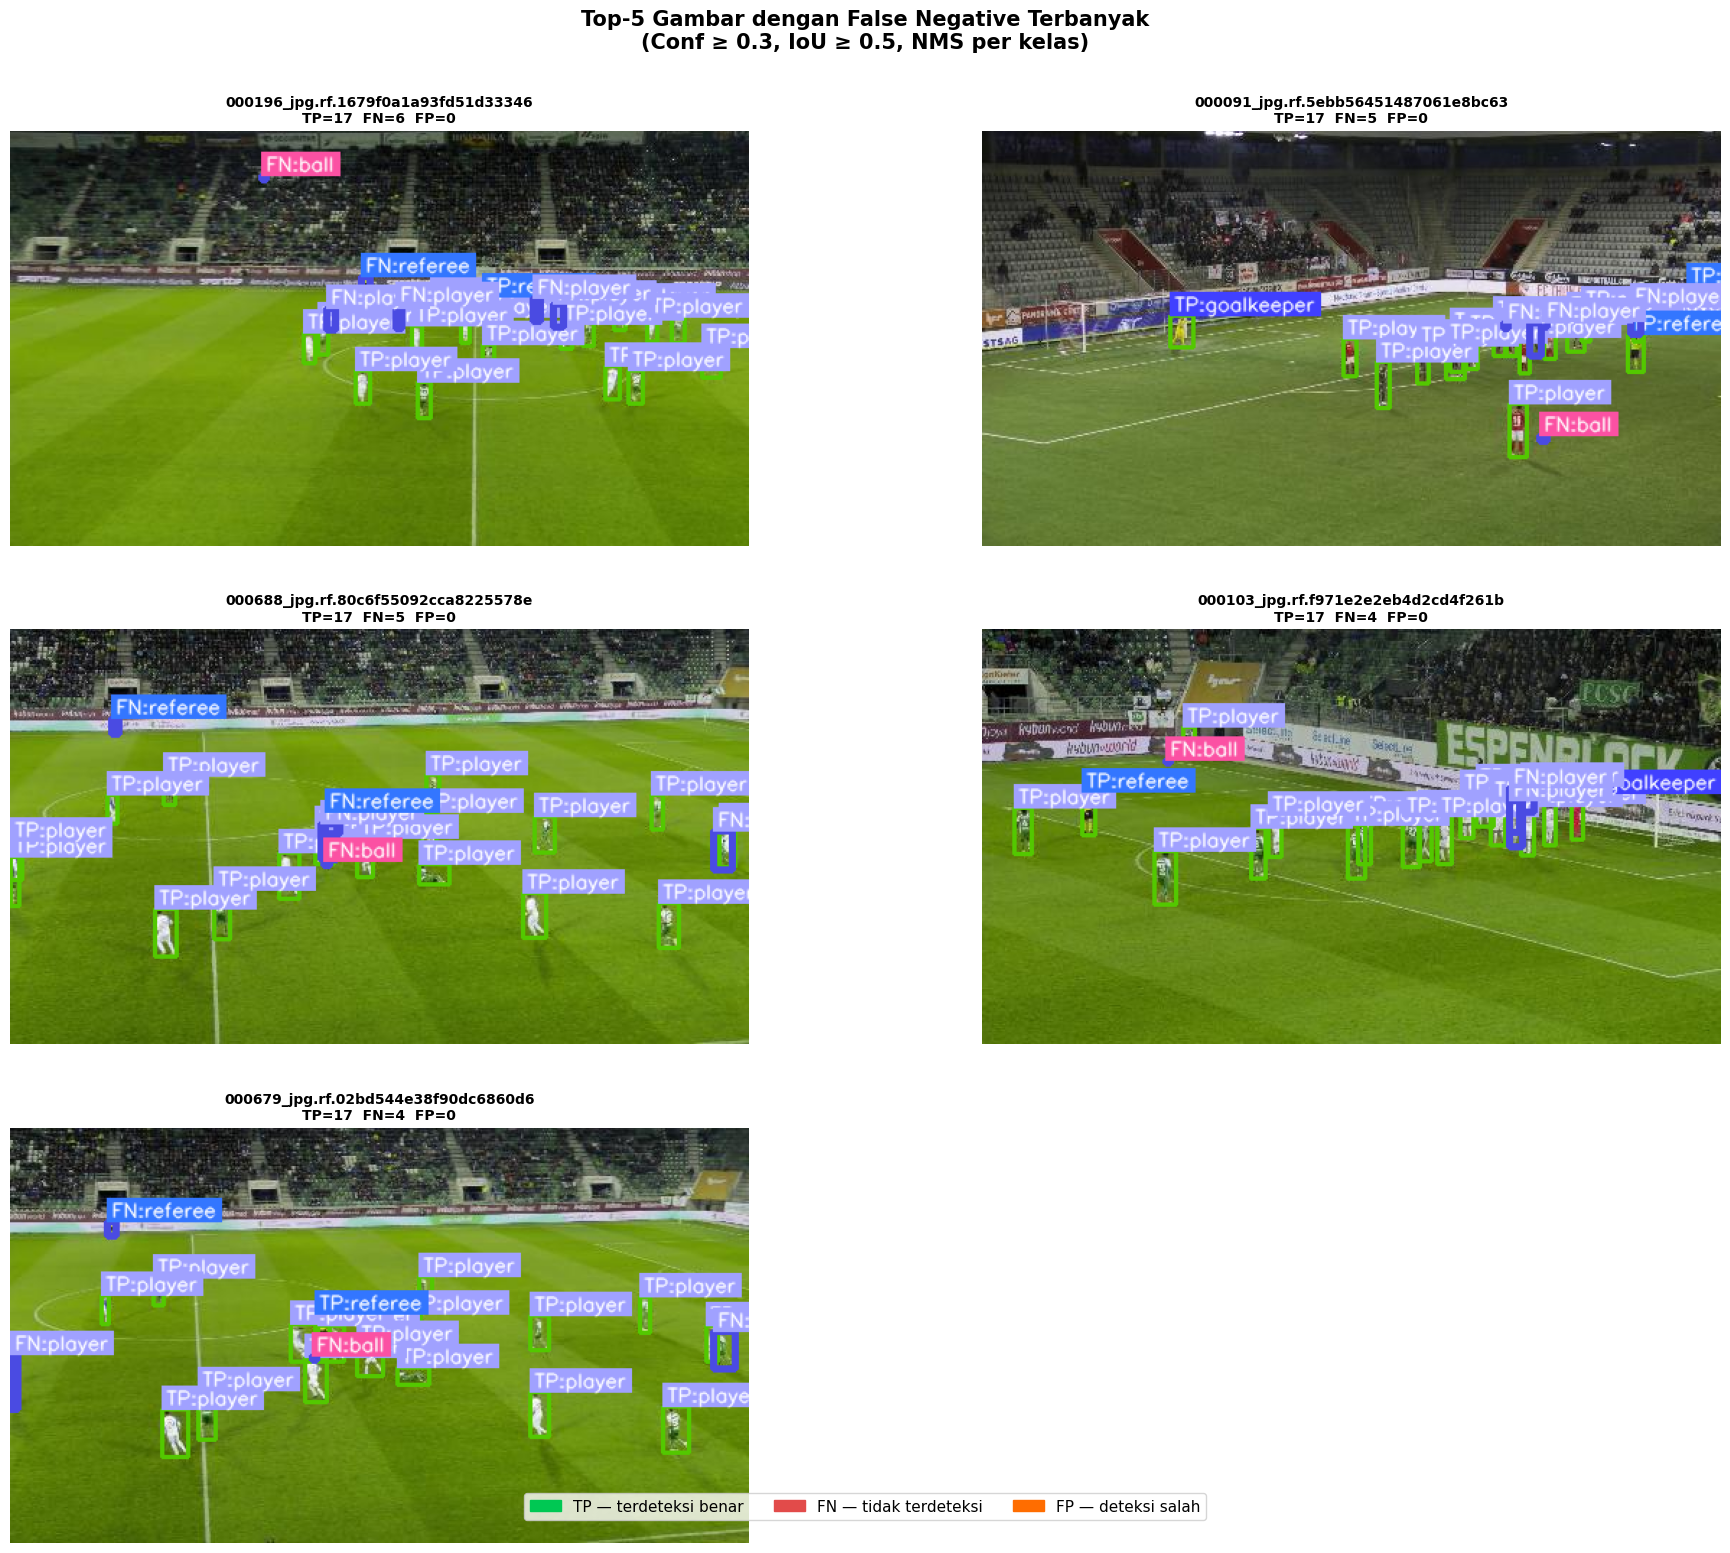

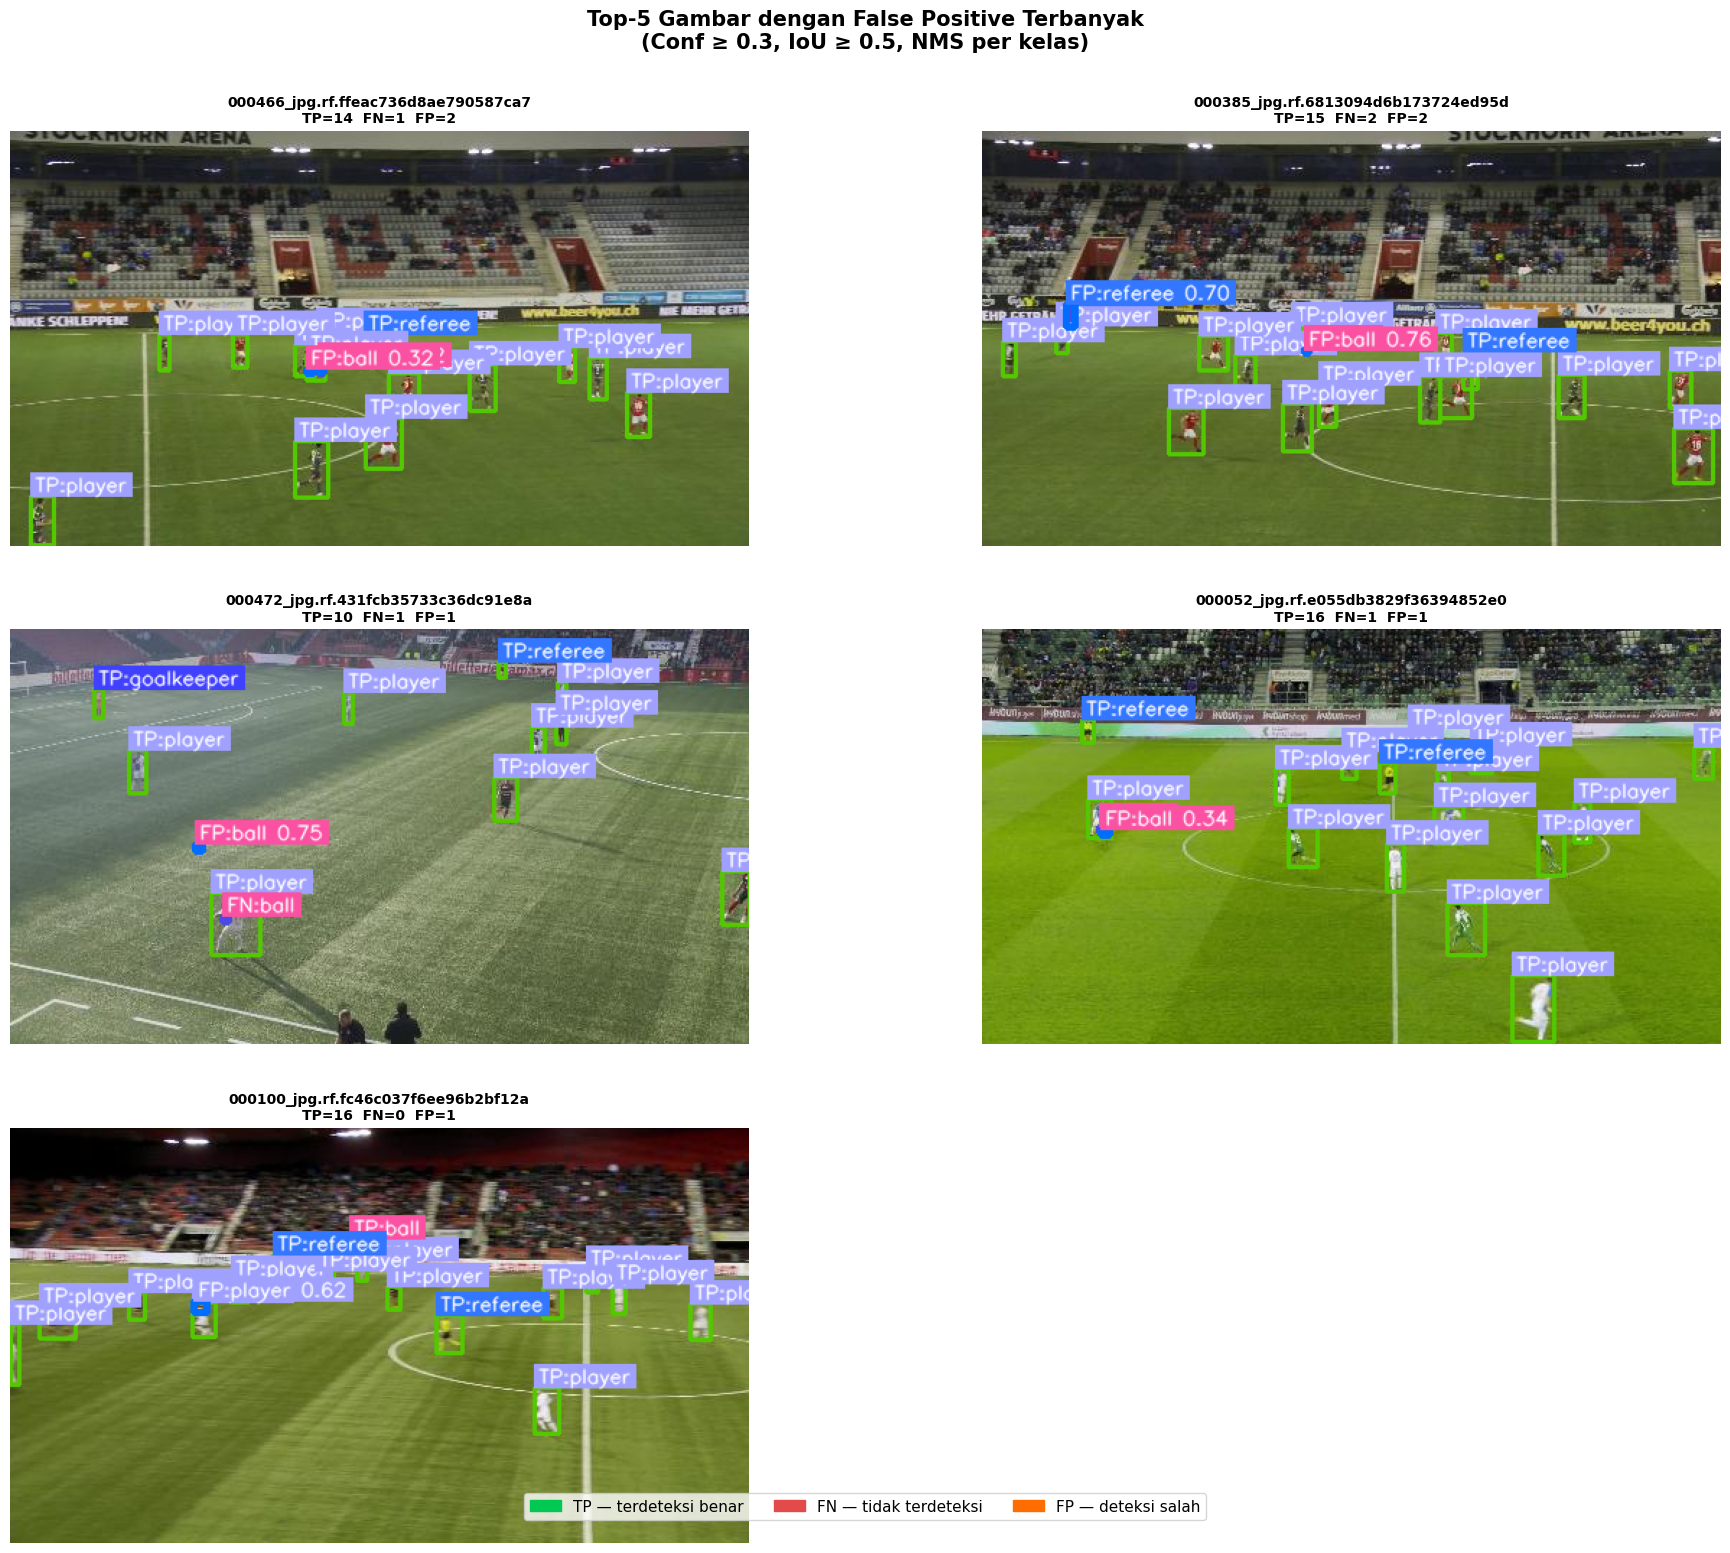

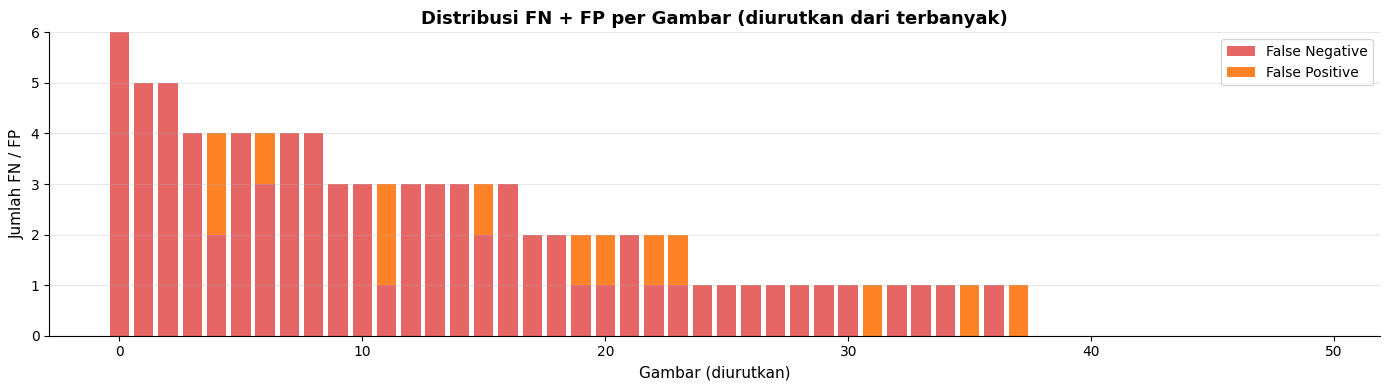


  Top-10 Gambar Terburuk  (FN + FP terbanyak)
 No  Nama File                                     TP    FN    FP   Total
------------------------------------------------------------------------
   1  000196_jpg.rf.1679f0a1a93fd51d3334678e05      17     6     0       6
   2  000091_jpg.rf.5ebb56451487061e8bc637dd52      17     5     0       5
   3  000688_jpg.rf.80c6f55092cca8225578e0e1ab      17     5     0       5
   4  000103_jpg.rf.f971e2e2eb4d2cd4f261bbf97e      17     4     0       4
   5  000385_jpg.rf.6813094d6b173724ed95daf6a1      15     2     2       4
   6  000679_jpg.rf.02bd544e38f90dc6860d61b520      17     4     0       4
   7  000643_jpg.rf.620de42dbf58e593a5a9b8b9b3      16     3     1       4
   8  000268_jpg.rf.7f8b6de0171f8a47cdf7eec8e9      17     4     0       4
   9  000322_jpg.rf.25b777a9d4324ae0251430f947      17     4     0       4
  10  000355_jpg.rf.65ed2e1035d72510cae9a50ef8      17     3     0       3

  Ringkasan keseluruhan:
  TP=787  FN=79  FP=13
  Recal

In [279]:
# ============================================================
# KONFIGURASI
# ============================================================
# class_names    = ['ball', 'goalkeeper', 'player', 'referee']
# num_classes    = len(class_names)
# CONF_THRESHOLD = 0.3
# IOU_THRESHOLD  = 0.5
NMS_THRESHOLD  = 0.5    # NMS per kelas (lebih konservatif)
TOP_N          = 5

def gt_to_idx(coco_id):
    return int(coco_id) - 1

def pred_to_idx(raw_id):
    return int(int(raw_id) % 5) - 1

def is_valid_idx(idx):
    return 0 <= idx <= (num_classes - 1)

def convert_pred(pred):
    """Konversi raw class_id → 0-based, filter invalid, NMS per kelas."""
    if len(pred) == 0:
        return pred
    pred_idx_list = [pred_to_idx(c) for c in pred.class_id]
    valid_mask    = np.array([is_valid_idx(i) for i in pred_idx_list])
    pred = pred[valid_mask]
    if len(pred) == 0:
        return pred
    pred.class_id = np.array([i for i, v in zip(pred_idx_list, valid_mask) if v])
    # NMS per kelas — tidak hapus deteksi berbeda kelas yang box-nya overlap
    pred = pred.with_nms(threshold=NMS_THRESHOLD, class_agnostic=False)
    return pred

def convert_gt(gt):
    """Konversi COCO id → 0-based, filter invalid."""
    if len(gt) == 0:
        return gt
    gt_idx_list = [gt_to_idx(c) for c in gt.class_id]
    valid_mask  = np.array([is_valid_idx(i) for i in gt_idx_list])
    gt = gt[valid_mask]
    if len(gt) > 0:
        gt.class_id = np.array([i for i, v in zip(gt_idx_list, valid_mask) if v])
    return gt

# ============================================================
# EVALUASI: Hitung FN dan FP per gambar
# ============================================================
results = []

for path, image_np, gt in tqdm(ds, desc="Evaluasi per gambar"):
    image = Image.open(path)
    pred  = model.predict(image, threshold=CONF_THRESHOLD)

    gt   = convert_gt(gt)
    pred = convert_pred(pred)

    gt_classes   = gt.class_id   if len(gt)   > 0 else np.array([], dtype=int)
    pred_classes = pred.class_id if len(pred) > 0 else np.array([], dtype=int)
    gt_boxes     = gt.xyxy       if len(gt)   > 0 else np.empty((0, 4))
    pred_boxes   = pred.xyxy     if len(pred) > 0 else np.empty((0, 4))

    matched_gt   = np.zeros(len(gt_classes),   dtype=bool)
    matched_pred = np.zeros(len(pred_classes), dtype=bool)

    if len(gt_classes) > 0 and len(pred_classes) > 0:
        iou_matrix = sv.box_iou_batch(pred_boxes, gt_boxes)
        pairs = [
            (iou_matrix[pi, gi], pi, gi)
            for pi in range(len(pred_classes))
            for gi in range(len(gt_classes))
            if iou_matrix[pi, gi] >= IOU_THRESHOLD
        ]
        pairs.sort(key=lambda x: -x[0])
        for iou_val, pi, gi in pairs:
            if matched_pred[pi] or matched_gt[gi]:
                continue
            matched_gt[gi]   = True
            matched_pred[pi] = True

    fn_mask = ~matched_gt
    fp_mask = ~matched_pred

    results.append({
        'path'         : path,
        'fn_count'     : int(fn_mask.sum()),
        'fp_count'     : int(fp_mask.sum()),
        'tp_count'     : int(matched_gt.sum()),
        'fn_detections': gt[fn_mask]     if len(gt)   > 0 else sv.Detections.empty(),
        'fp_detections': pred[fp_mask]   if len(pred) > 0 else sv.Detections.empty(),
        'tp_gt'        : gt[matched_gt]  if len(gt)   > 0 else sv.Detections.empty(),
        'tp_pred'      : pred[matched_pred] if len(pred) > 0 else sv.Detections.empty(),
    })

total_fn = sum(r['fn_count'] for r in results)
total_fp = sum(r['fp_count'] for r in results)
total_tp = sum(r['tp_count'] for r in results)
print(f"\nSelesai evaluasi {len(results)} gambar.")
print(f"Total TP={total_tp}  |  FN={total_fn}  |  FP={total_fp}")
print(f"Recall keseluruhan  : {total_tp / (total_tp + total_fn + 1e-9):.4f}")
print(f"Precision keseluruhan: {total_tp / (total_tp + total_fp + 1e-9):.4f}")

# ============================================================
# FUNGSI ANNOTASI
# ============================================================
def annotate_image(img_array, tp_gt, fn_det, fp_det):
    canvas    = img_array.copy()
    label_ann = sv.LabelAnnotator(text_scale=0.45, text_padding=3, text_thickness=1)

    # TP: hijau
    if len(tp_gt) > 0:
        ann = sv.BoxAnnotator(color=sv.Color.from_hex('#00C853'), thickness=2)
        lbl = [f"TP:{class_names[c]}" for c in tp_gt.class_id]
        canvas = ann.annotate(canvas, tp_gt)
        canvas = label_ann.annotate(canvas, tp_gt, lbl)

    # FN: merah tebal
    if len(fn_det) > 0:
        ann = sv.BoxAnnotator(color=sv.Color.from_hex('#E24B4A'), thickness=3)
        lbl = [f"FN:{class_names[c]}" for c in fn_det.class_id]
        canvas = ann.annotate(canvas, fn_det)
        canvas = label_ann.annotate(canvas, fn_det, lbl)

    # FP: oranye tebal + confidence
    if len(fp_det) > 0:
        ann = sv.BoxAnnotator(color=sv.Color.from_hex('#FF6D00'), thickness=3)
        if fp_det.confidence is not None:
            lbl = [f"FP:{class_names[c]} {s:.2f}"
                   for c, s in zip(fp_det.class_id, fp_det.confidence)]
        else:
            lbl = [f"FP:{class_names[c]}" for c in fp_det.class_id]
        canvas = ann.annotate(canvas, fp_det)
        canvas = label_ann.annotate(canvas, fp_det, lbl)

    return canvas

legend_handles = [
    mpatches.Patch(color='#00C853', label='TP — terdeteksi benar'),
    mpatches.Patch(color='#E24B4A', label='FN — tidak terdeteksi'),
    mpatches.Patch(color='#FF6D00', label='FP — deteksi salah'),
]

# ============================================================
# HELPER: Plot grid gambar (baris × kolom, tiap gambar lebih besar)
# ============================================================
def plot_worst_grid(records, title, n_cols=2, img_size=8):
    """
    Tampilkan gambar dalam grid n_cols kolom.
    img_size = ukuran tiap gambar dalam inci (makin besar makin jelas).
    """
    n      = len(records)
    n_rows = int(np.ceil(n / n_cols))
    fig_w  = img_size * n_cols
    # fig_h  = img_size * n_rows + 1.2   # +1.2 untuk legend & suptitle
    sample = np.array(Image.open(records[0]['path']))
    aspect = sample.shape[0] / sample.shape[1]   # h/w, misal 0.5625 untuk 16:9
    fig_h  = img_size * aspect * n_rows          # bukan + 1.2 lagi

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(fig_w, fig_h))
    # Pastikan axes selalu 2D
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    for idx, r in enumerate(records):
        row = idx // n_cols
        col = idx  % n_cols
        ax  = axes[row, col]

        img    = np.array(Image.open(r['path']))
        canvas = annotate_image(img, r['tp_gt'],
                                r['fn_detections'],
                                r['fp_detections'])
        ax.imshow(canvas)
        ax.set_title(
            f"{os.path.basename(r['path'])[:35]}\n"
            f"TP={r['tp_count']}  FN={r['fn_count']}  FP={r['fp_count']}",
            fontsize=10, fontweight='bold', pad=6
        )
        ax.axis('off')

    # Sembunyikan subplot kosong (jika n tidak habis dibagi n_cols)
    for idx in range(n, n_rows * n_cols):
        row = idx // n_cols
        col = idx  % n_cols
        axes[row, col].set_visible(False)

    legend_handles = [
        mpatches.Patch(color='#00C853', label='TP — terdeteksi benar'),
        mpatches.Patch(color='#E24B4A', label='FN — tidak terdeteksi'),
        mpatches.Patch(color='#FF6D00', label='FP — deteksi salah'),
    ]
    fig.legend(handles=legend_handles,
               loc='lower center', ncol=3,
               fontsize=11, frameon=True,
               bbox_to_anchor=(0.5, 0.01))
    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.01)
    # plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.subplots_adjust(left=0.005, right=0.995, top=0.93, bottom=0.0)
    plt.show()


# ============================================================
# PLOT 1: Top-5 gambar FN terbanyak — grid 2 kolom
# ============================================================
worst_fn = sorted(results, key=lambda x: x['fn_count'], reverse=True)[:TOP_N]

plot_worst_grid(
    records  = worst_fn,
    title    = (f'Top-{TOP_N} Gambar dengan False Negative Terbanyak\n'
                f'(Conf ≥ {CONF_THRESHOLD}, IoU ≥ {IOU_THRESHOLD}, NMS per kelas)'),
    n_cols   = 2,      # ← ganti 3 untuk 3 kolom, 1 untuk 1 kolom
    img_size = 9       # ← makin besar makin detail (satuan inci)
)

# ============================================================
# PLOT 2: Top-5 gambar FP terbanyak — grid 2 kolom
# ============================================================
worst_fp = sorted(results, key=lambda x: x['fp_count'], reverse=True)[:TOP_N]

plot_worst_grid(
    records  = worst_fp,
    title    = (f'Top-{TOP_N} Gambar dengan False Positive Terbanyak\n'
                f'(Conf ≥ {CONF_THRESHOLD}, IoU ≥ {IOU_THRESHOLD}, NMS per kelas)'),
    n_cols   = 2,
    img_size = 9
)

# ============================================================
# PLOT 3: Bar chart FN + FP per gambar
# ============================================================
sorted_by_total = sorted(results,
                          key=lambda x: x['fn_count'] + x['fp_count'],
                          reverse=True)
fn_counts = [r['fn_count'] for r in sorted_by_total]
fp_counts = [r['fp_count'] for r in sorted_by_total]
x_idx     = range(len(sorted_by_total))

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(x_idx, fn_counts, color='#E24B4A', alpha=0.85, label='False Negative')
ax.bar(x_idx, fp_counts, bottom=fn_counts,
       color='#FF6D00', alpha=0.85, label='False Positive')
ax.set_title('Distribusi FN + FP per Gambar (diurutkan dari terbanyak)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Gambar (diurutkan)', fontsize=11)
ax.set_ylabel('Jumlah FN / FP', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# ============================================================
# TABEL RINGKASAN
# ============================================================
print(f"\n{'='*72}")
print(f"  Top-10 Gambar Terburuk  (FN + FP terbanyak)")
print(f"{'='*72}")
print(f"{'No':>3}  {'Nama File':<42}  {'TP':>4}  {'FN':>4}  {'FP':>4}  {'Total':>6}")
print(f"{'-'*72}")
for rank, r in enumerate(sorted_by_total[:10], 1):
    fname = os.path.basename(r['path'])[:40]
    total = r['fn_count'] + r['fp_count']
    print(f"  {rank:>2}  {fname:<42}  {r['tp_count']:>4}  "
          f"{r['fn_count']:>4}  {r['fp_count']:>4}  {total:>6}")
print(f"{'='*72}")
print(f"\n  Ringkasan keseluruhan:")
print(f"  TP={total_tp}  FN={total_fn}  FP={total_fp}")
print(f"  Recall   = {total_tp/(total_tp+total_fn+1e-9):.4f}")
print(f"  Precision = {total_tp/(total_tp+total_fp+1e-9):.4f}")

*🔍 Analisis False Negative & False Positive*

##### Kode Warna pada Anotasi

| Warna | Kode | Artinya |
|-------|------|---------|
| 🟢 Hijau | TP | Objek berhasil dideteksi dengan kelas yang benar |
| 🔴 Merah | FN | Objek ada di GT tapi **tidak terdeteksi** model |
| 🟠 Oranye | FP | Model mendeteksi sesuatu tapi **tidak ada GT**-nya |


**Ringkasan Hasil**

| Metrik | Nilai | Interpretasi |
|--------|-------|-------------|
| **TP** | 787 | Objek yang berhasil dideteksi dengan benar |
| **FN** | 79 | Objek yang ada di dataset tapi **tidak terdeteksi** model |
| **FP** | 13 | Deteksi model yang **tidak ada pasangan GT**-nya |
| **Recall** | 0.9088 | 90.88% objek berhasil ditemukan |
| **Precision** | 0.9837 | 98.37% prediksi model adalah benar |

##### Mengapa FN lebih banyak dari FP?

Ini adalah pola yang **wajar dan justru positif** pada model object detection.
Artinya model bersifat **konservatif** — lebih memilih untuk tidak mendeteksi
daripada mendeteksi sesuatu yang tidak yakin. Hal ini jauh lebih baik
dibanding model yang terlalu banyak False Positive (mendeteksi benda yang
tidak ada).

#### Analisis Gambar dengan FN Terbanyak

Dari visualisasi Top-5 gambar FN terbanyak, terlihat pola kegagalan model:

- **Gambar ramai (banyak pemain bertumpuk)** — objek yang saling overlap
  menyulitkan model untuk memisahkan tiap individu. Gambar dengan FN=6
  (000196) menunjukkan banyak pemain berdekatan di area yang sama.
- **Objek kecil (bola)** — bola (`ball`) yang jauh dari kamera atau
  tertutup sebagian oleh pemain sering terlewat.
- **Objek di tepi frame** — beberapa FN terjadi pada objek yang hanya
  terlihat sebagian di pinggir gambar.

##### Analisis Gambar dengan FP Terbanyak

FP hanya berjumlah 13 di seluruh test set (rata-rata 0.26 per gambar),
yang mengindikasikan model jarang melakukan deteksi palsu. Dari visualisasi,
FP yang terjadi umumnya adalah:

- Deteksi **bola** di area yang secara visual mirip dengan bola
  (misalnya kepala pemain atau logo lapangan).
- Deteksi **wasit/referee** yang posisinya jauh dan ukurannya mirip pemain.

##### Kesimpulan

Model RF-DETR menunjukkan performa yang sangat baik dengan precision tinggi
(98.37%) yang berarti deteksi yang dilakukan hampir selalu benar. Area
yang masih dapat ditingkatkan adalah recall — terutama untuk mendeteksi
objek dalam kondisi crowded (banyak pemain bertumpuk) dan objek berukuran
kecil seperti bola dari jarak jauh.

============================================================================================================================================================================================================================================================================================================================================================

#### Penjelasan False Negative (FN) dan False Positive (FP)

Bayangkan kamu minta model untuk **menunjuk semua pemain di lapangan**. Di lapangan ada **22 pemain nyata** (Ground Truth). Model membuat prediksinya sendiri.

---

##### Pengertian Singkat

| Istilah | Model | Kenyataan | Artinya |
|---------|-------|-----------|---------|
| **True Positive (TP)** | Mendeteksi ✓ | Ada ✓ | Benar — ditemukan dan memang ada |
| **False Negative (FN)** | Tidak mendeteksi ✗ | Ada ✓ | Model **melewatkan** objek yang nyata |
| **False Positive (FP)** | Mendeteksi ✓ | Tidak ada ✗ | Model **salah tunjuk** — mendeteksi sesuatu yang tidak ada |

---

##### 🔴 False Negative — "Yang Kelewatan"

> **Analogi: Wartawan foto yang melewatkan momen**
>
> Ada 22 pemain di lapangan. Wartawan hanya memotret 18 orang.
> **4 pemain yang tidak dipotret = FN.**
> Mereka nyata, tapi tidak terdeteksi kamera.

Dalam RF-DETR: model **melewatkan bola** yang ada di dataset karena terlalu kecil atau tertutup kaki pemain. Bola itu nyata (ada di GT), tapi model tidak menemukannya.

---

##### 🟠 False Positive — "Yang Salah Tunjuk"

> **Analogi: Satpam yang salah menangkap orang**
>
> Satpam berteriak "Ada penyusup!" tapi yang ditangkap ternyata karyawan biasa.
> **Laporan salah = FP.**
> Ada deteksi, tapi salah sasaran.

Dalam RF-DETR: model mendeteksi "ada bola!" tapi ternyata itu hanya **kepala pemain** atau logo di lapangan. Tidak ada GT untuk objek itu, tapi model tetap mendeteksinya.

---

##### Ringkasan Satu Kalimat

- 🔴 **FN** = Objek *nyata* yang *tidak ditemukan* model → model **kurang sensitif**
- 🟠 **FP** = Deteksi model yang *tidak ada padanannya di kenyataan* → model **terlalu percaya diri**
- 🟢 **TP** = Deteksi model yang *benar* dan ada padanannya di GT → ini yang kita inginkan

---

##### Hubungan dengan Precision dan Recall

| Metrik | Dipengaruhi oleh | Artinya jika rendah |
|--------|-----------------|---------------------|
| **Recall** | FN | Banyak objek nyata yang terlewat |
| **Precision** | FP | Banyak deteksi yang salah sasaran |

---

##### Konteks Hasil RF-DETR

Dari hasil evaluasi model RF-DETR pada dataset ini didapatkan **FN=79** jauh lebih besar dari **FP=13**. Artinya model lebih sering *melewatkan objek* (terutama bola yang kecil) daripada *salah mendeteksi*. Ini sebenarnya pola yang bagus — lebih baik model hati-hati daripada asal tunjuk.

# Summary Info

Evaluasi: 100%|██████████| 50/50 [00:23<00:00,  2.12it/s]


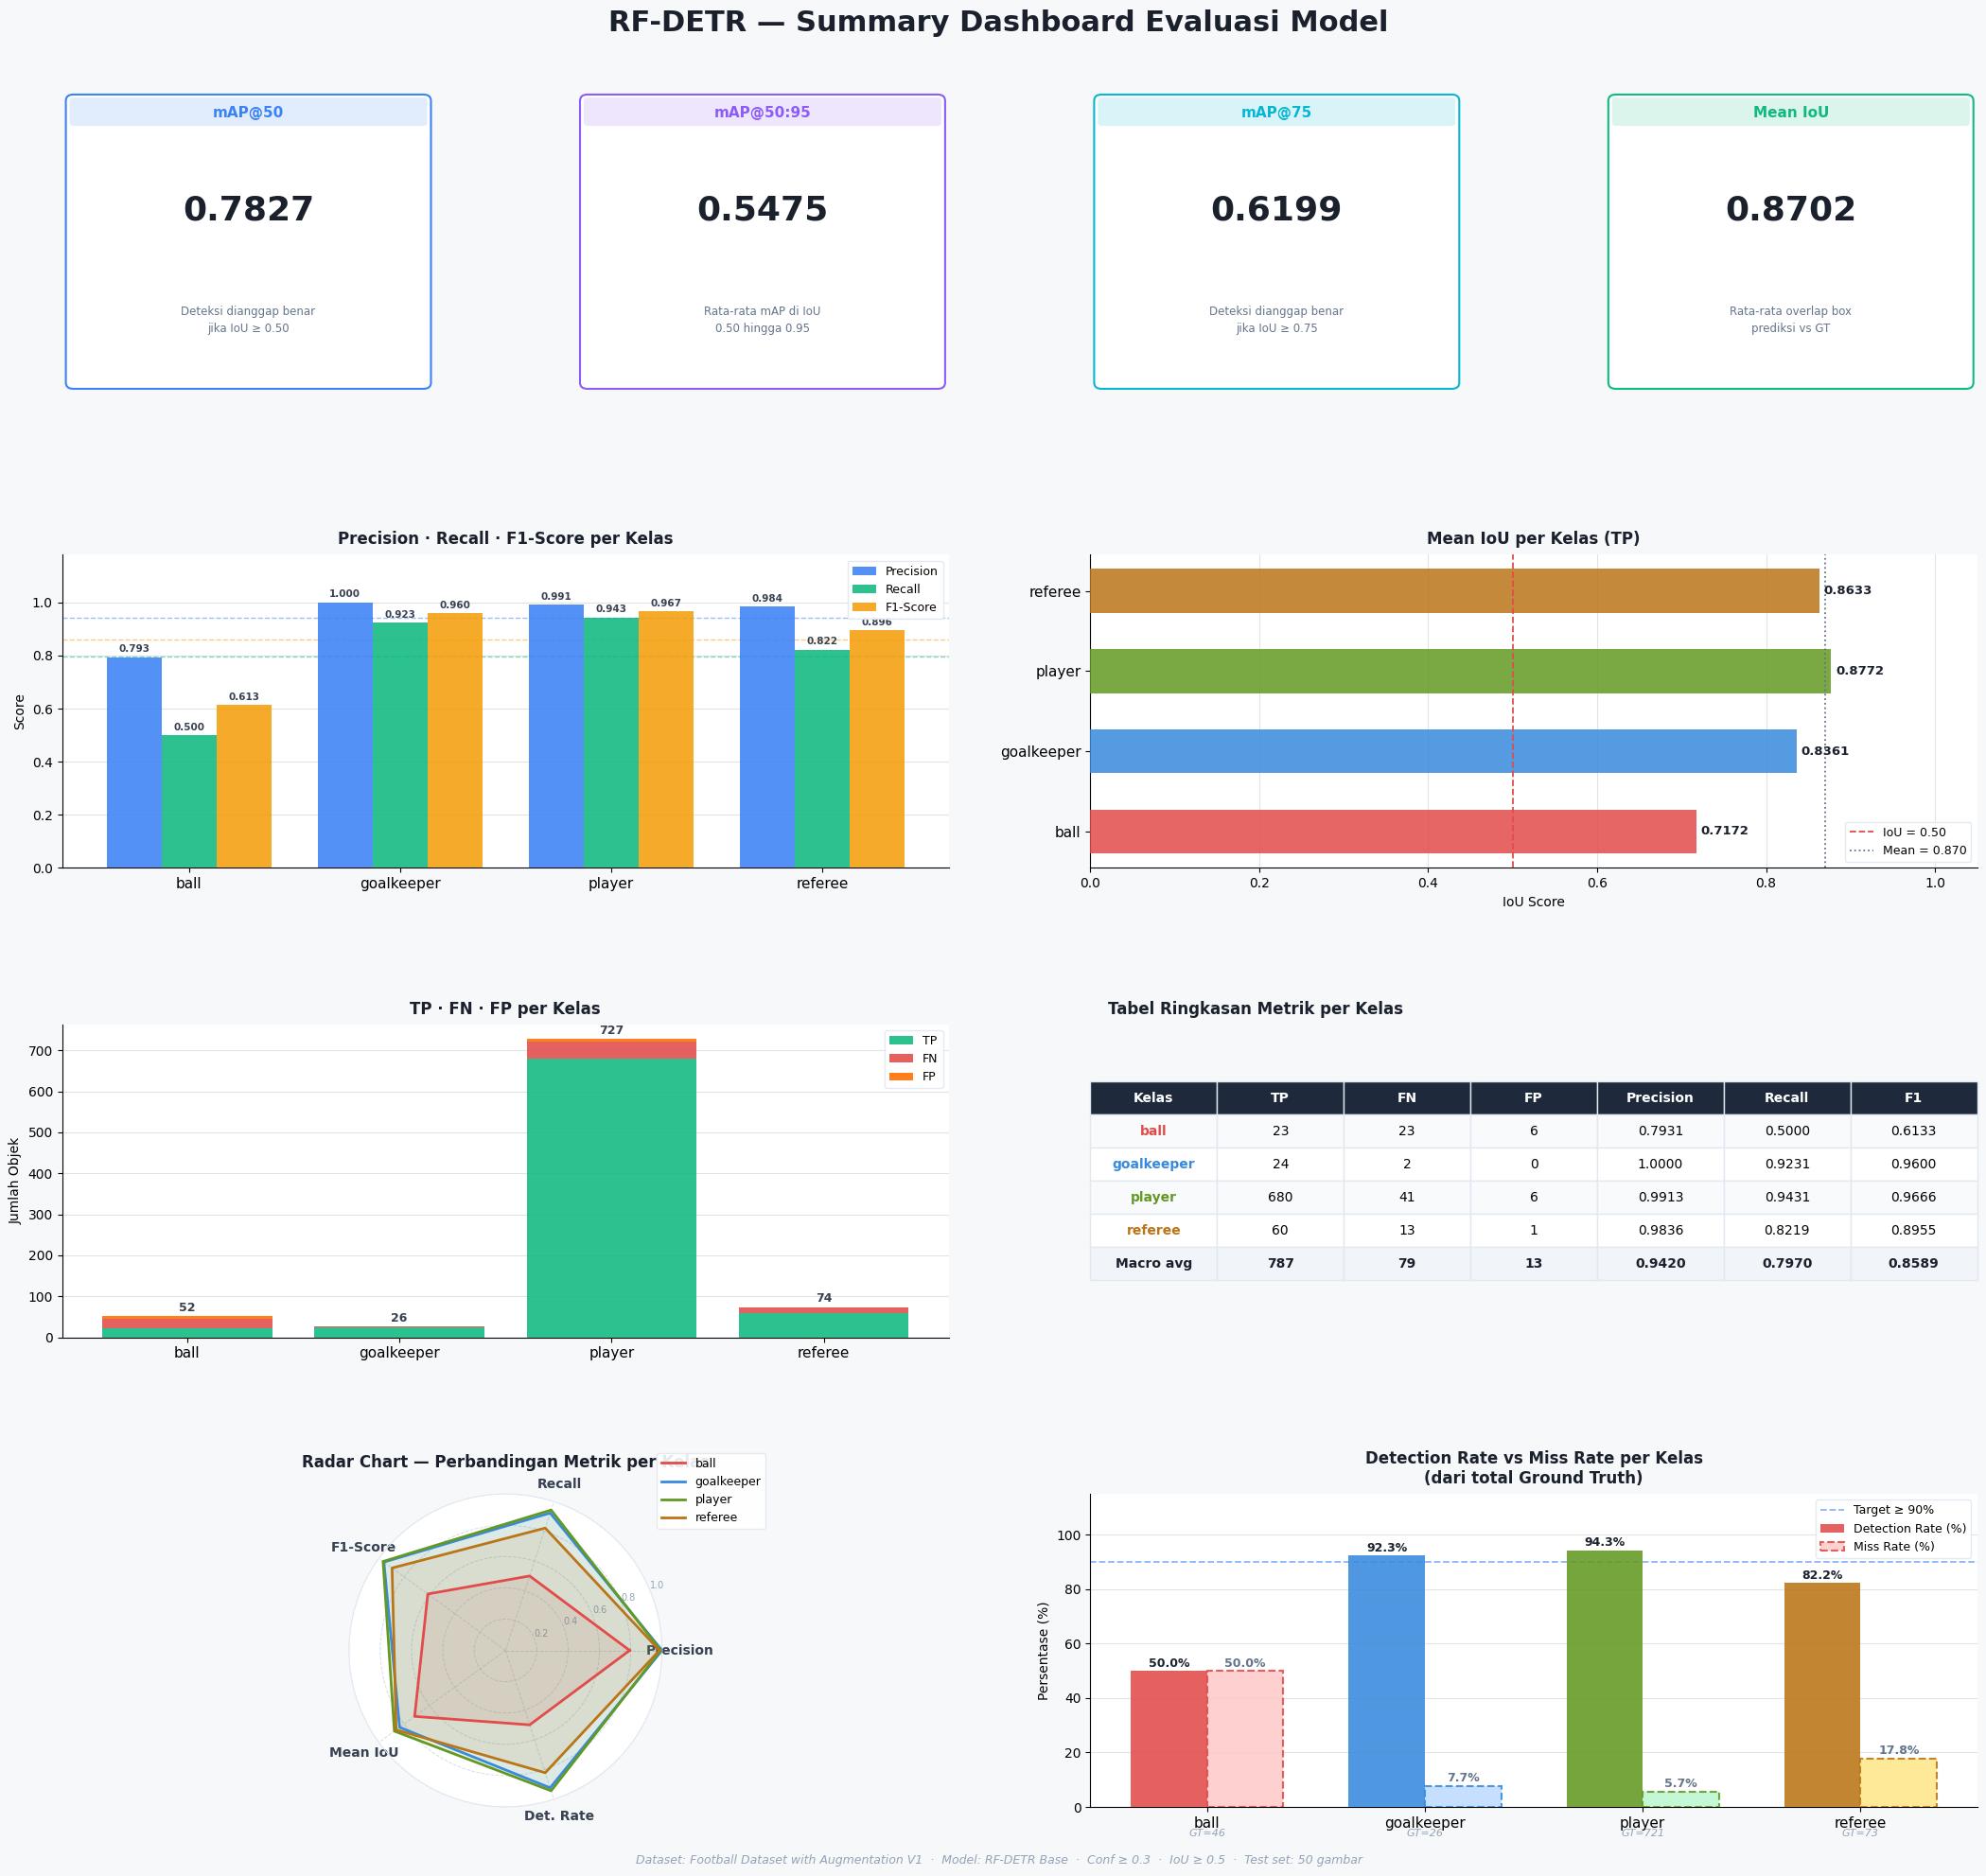

Dashboard tersimpan sebagai 'rfdetr_dashboard_v2.png'


In [272]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from PIL import Image
from tqdm import tqdm
import supervision as sv

# ============================================================
# KONFIGURASI
# ============================================================
class_names    = ['ball', 'goalkeeper', 'player', 'referee']
num_classes    = len(class_names)
CONF_THRESHOLD = 0.3
IOU_THRESHOLD  = 0.5

CLASS_COLORS = ['#E24B4A', '#378ADD', '#639922', '#BA7517']
BG_COLOR     = '#F7F8FA'
CARD_COLOR   = '#FFFFFF'
BORDER_COLOR = '#E2E8F0'

def gt_to_idx(coco_id):  return int(coco_id) - 1
def pred_to_idx(raw_id): return int(int(raw_id) % 5) - 1
def is_valid_idx(idx):   return 0 <= idx <= (num_classes - 1)

def convert_pred(pred):
    if len(pred) == 0: return pred
    pred_idx_list = [pred_to_idx(c) for c in pred.class_id]
    valid_mask    = np.array([is_valid_idx(i) for i in pred_idx_list])
    pred = pred[valid_mask]
    if len(pred) == 0: return pred
    pred.class_id = np.array([i for i, v in zip(pred_idx_list, valid_mask) if v])
    return pred.with_nms(threshold=0.5, class_agnostic=False)

def convert_gt(gt):
    if len(gt) == 0: return gt
    gt_idx_list = [gt_to_idx(c) for c in gt.class_id]
    valid_mask  = np.array([is_valid_idx(i) for i in gt_idx_list])
    gt = gt[valid_mask]
    if len(gt) > 0:
        gt.class_id = np.array([i for i, v in zip(gt_idx_list, valid_mask) if v])
    return gt

# ============================================================
# EVALUASI
# ============================================================
tp_per_class   = np.zeros(num_classes, dtype=int)
fp_per_class   = np.zeros(num_classes, dtype=int)
fn_per_class   = np.zeros(num_classes, dtype=int)
iou_per_class  = [[] for _ in range(num_classes)]
total_gt_class = np.zeros(num_classes, dtype=int)

for path, image_np, gt in tqdm(ds, desc="Evaluasi"):
    image = Image.open(path)
    pred  = model.predict(image, threshold=CONF_THRESHOLD)
    gt    = convert_gt(gt)
    pred  = convert_pred(pred)

    if len(gt) > 0:
        for c in gt.class_id:
            if is_valid_idx(c): total_gt_class[c] += 1

    gt_classes   = gt.class_id   if len(gt)   > 0 else np.array([], dtype=int)
    pred_classes = pred.class_id if len(pred) > 0 else np.array([], dtype=int)
    gt_boxes     = gt.xyxy       if len(gt)   > 0 else np.empty((0, 4))
    pred_boxes   = pred.xyxy     if len(pred) > 0 else np.empty((0, 4))

    matched_gt   = np.zeros(len(gt_classes),   dtype=bool)
    matched_pred = np.zeros(len(pred_classes), dtype=bool)

    if len(gt_classes) > 0 and len(pred_classes) > 0:
        iou_matrix = sv.box_iou_batch(pred_boxes, gt_boxes)
        pairs = [(iou_matrix[pi, gi], pi, gi)
                 for pi in range(len(pred_classes))
                 for gi in range(len(gt_classes))
                 if iou_matrix[pi, gi] >= IOU_THRESHOLD]
        pairs.sort(key=lambda x: -x[0])
        for iou_val, pi, gi in pairs:
            if matched_pred[pi] or matched_gt[gi]: continue
            matched_gt[gi] = matched_pred[pi] = True
            tc, pc = gt_classes[gi], pred_classes[pi]
            if tc == pc:
                tp_per_class[tc] += 1
                iou_per_class[tc].append(iou_val)

    for gi in range(len(gt_classes)):
        if not matched_gt[gi]: fn_per_class[gt_classes[gi]] += 1
    for pi in range(len(pred_classes)):
        if not matched_pred[pi]: fp_per_class[pred_classes[pi]] += 1

# ============================================================
# HITUNG METRIK
# ============================================================
precision_cls   = tp_per_class / (tp_per_class + fp_per_class + 1e-9)
recall_cls      = tp_per_class / (tp_per_class + fn_per_class + 1e-9)
f1_cls          = 2 * precision_cls * recall_cls / (precision_cls + recall_cls + 1e-9)
mean_iou_cls    = np.array([np.mean(iou_per_class[i]) if iou_per_class[i] else 0.0
                             for i in range(num_classes)])
detection_rate  = tp_per_class / (total_gt_class + 1e-9)  # % GT yang terdeteksi

macro_precision = precision_cls.mean()
macro_recall    = recall_cls.mean()
macro_f1        = f1_cls.mean()
mean_iou_all    = np.mean([v for s in iou_per_class for v in s]) if any(iou_per_class) else 0.0

map50   = float(map_result.map50)
map5095 = float(map_result.map50_95)
map75   = float(map_result.map75)

# ============================================================
# DASHBOARD: 4 baris × 4 kolom
# ============================================================
fig = plt.figure(figsize=(22, 20), facecolor=BG_COLOR)
fig.suptitle('RF-DETR — Summary Dashboard Evaluasi Model',
             fontsize=22, fontweight='bold', color='#1A202C', y=0.99)

gs = gridspec.GridSpec(
    4, 4,
    figure=fig,
    hspace=0.50,
    wspace=0.38,
    left=0.05, right=0.97,
    top=0.95,  bottom=0.04
)

# -------------------------------------------------------
# BARIS 1: 4 Metric Cards
# -------------------------------------------------------
card_metrics = [
    ('mAP@50',    map50,        '#3B82F6', 'Deteksi dianggap benar\njika IoU ≥ 0.50'),
    ('mAP@50:95', map5095,      '#8B5CF6', 'Rata-rata mAP di IoU\n0.50 hingga 0.95'),
    ('mAP@75',    map75,        '#06B6D4', 'Deteksi dianggap benar\njika IoU ≥ 0.75'),
    ('Mean IoU',  mean_iou_all, '#10B981', 'Rata-rata overlap box\nprediksi vs GT'),
]
for col, (label, val, color, desc) in enumerate(card_metrics):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor(CARD_COLOR)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03, 0.05), 0.94, 0.90,
        boxstyle="round,pad=0.02", linewidth=1.5, edgecolor=color,
        facecolor=CARD_COLOR, zorder=1, transform=ax.transAxes))
    ax.add_patch(FancyBboxPatch((0.03, 0.88), 0.94, 0.07,
        boxstyle="round,pad=0.01", linewidth=0, facecolor=color,
        alpha=0.15, transform=ax.transAxes, zorder=2))
    ax.text(0.5, 0.91, label, transform=ax.transAxes, ha='center', va='center',
            fontsize=11, fontweight='bold', color=color, zorder=3)
    ax.text(0.5, 0.60, f'{val:.4f}', transform=ax.transAxes,
            ha='center', va='center', fontsize=26, fontweight='bold',
            color='#1A202C', zorder=3)
    ax.text(0.5, 0.25, desc, transform=ax.transAxes, ha='center', va='center',
            fontsize=8.5, color='#64748B', zorder=3, linespacing=1.5)

# -------------------------------------------------------
# BARIS 2 KIRI: Grouped bar — Precision / Recall / F1
# -------------------------------------------------------
ax_bar = fig.add_subplot(gs[1, :2])
ax_bar.set_facecolor(CARD_COLOR)

x     = np.arange(num_classes)
width = 0.26
bars_p = ax_bar.bar(x - width, precision_cls, width, label='Precision',
                    color='#3B82F6', alpha=0.88, zorder=3)
bars_r = ax_bar.bar(x,          recall_cls,    width, label='Recall',
                    color='#10B981', alpha=0.88, zorder=3)
bars_f = ax_bar.bar(x + width,  f1_cls,        width, label='F1-Score',
                    color='#F59E0B', alpha=0.88, zorder=3)

for bars in [bars_p, bars_r, bars_f]:
    for rect in bars:
        h = rect.get_height()
        ax_bar.text(rect.get_x() + rect.get_width()/2, h + 0.012,
                    f'{h:.3f}', ha='center', va='bottom',
                    fontsize=7.5, color='#374151', fontweight='bold', zorder=4)

ax_bar.set_title('Precision · Recall · F1-Score per Kelas',
                 fontsize=12, fontweight='bold', color='#1A202C', pad=8)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(class_names, fontsize=11)
ax_bar.set_ylabel('Score', fontsize=10)
ax_bar.set_ylim(0, 1.18)
ax_bar.set_xlim(-0.6, num_classes - 0.4)
ax_bar.legend(fontsize=9, loc='upper right', framealpha=0.9, edgecolor=BORDER_COLOR)
ax_bar.grid(axis='y', alpha=0.35, zorder=0)
ax_bar.set_axisbelow(True)
ax_bar.spines[['top', 'right']].set_visible(False)
for val, color, ls in [(macro_precision, '#3B82F6', '--'),
                        (macro_recall,    '#10B981', '--'),
                        (macro_f1,        '#F59E0B', '--')]:
    ax_bar.axhline(val, color=color, linestyle=ls, linewidth=1, alpha=0.5, zorder=2)

# -------------------------------------------------------
# BARIS 2 KANAN: Mean IoU horizontal bar
# -------------------------------------------------------
ax_iou = fig.add_subplot(gs[1, 2:])
ax_iou.set_facecolor(CARD_COLOR)

y_pos  = np.arange(num_classes)
bars_i = ax_iou.barh(y_pos, mean_iou_cls, color=CLASS_COLORS,
                      alpha=0.85, height=0.55, zorder=3)
ax_iou.axvline(0.5, color='#E24B4A', linestyle='--', linewidth=1.3,
               label='IoU = 0.50', zorder=4)
ax_iou.axvline(mean_iou_all, color='#64748B', linestyle=':',
               linewidth=1.3, label=f'Mean = {mean_iou_all:.3f}', zorder=4)

for bar, val in zip(bars_i, mean_iou_cls):
    ax_iou.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9.5,
                fontweight='bold', color='#1A202C', zorder=5)

ax_iou.set_title('Mean IoU per Kelas (TP)',
                 fontsize=12, fontweight='bold', color='#1A202C', pad=8)
ax_iou.set_yticks(y_pos)
ax_iou.set_yticklabels(class_names, fontsize=11)
ax_iou.set_xlabel('IoU Score', fontsize=10)
ax_iou.set_xlim(0, 1.05)
ax_iou.legend(fontsize=9, loc='lower right', framealpha=0.9, edgecolor=BORDER_COLOR)
ax_iou.grid(axis='x', alpha=0.35, zorder=0)
ax_iou.set_axisbelow(True)
ax_iou.spines[['top', 'right']].set_visible(False)

# -------------------------------------------------------
# BARIS 3 KIRI: TP / FN / FP stacked bar
# -------------------------------------------------------
ax_tp = fig.add_subplot(gs[2, :2])
ax_tp.set_facecolor(CARD_COLOR)

x3 = np.arange(num_classes)
ax_tp.bar(x3, tp_per_class, color='#10B981', alpha=0.88, label='TP', zorder=3)
ax_tp.bar(x3, fn_per_class, bottom=tp_per_class,
          color='#E24B4A', alpha=0.88, label='FN', zorder=3)
ax_tp.bar(x3, fp_per_class, bottom=tp_per_class + fn_per_class,
          color='#FF6D00', alpha=0.88, label='FP', zorder=3)

for i in range(num_classes):
    total = tp_per_class[i] + fn_per_class[i] + fp_per_class[i]
    ax_tp.text(i, total + 5, str(total), ha='center', va='bottom',
               fontsize=9, fontweight='bold', color='#374151', zorder=4)

ax_tp.set_title('TP · FN · FP per Kelas',
                fontsize=12, fontweight='bold', color='#1A202C', pad=8)
ax_tp.set_xticks(x3)
ax_tp.set_xticklabels(class_names, fontsize=11)
ax_tp.set_ylabel('Jumlah Objek', fontsize=10)
ax_tp.legend(fontsize=9, loc='upper right', framealpha=0.9, edgecolor=BORDER_COLOR)
ax_tp.grid(axis='y', alpha=0.35, zorder=0)
ax_tp.set_axisbelow(True)
ax_tp.spines[['top', 'right']].set_visible(False)

# -------------------------------------------------------
# BARIS 3 KANAN: Tabel ringkasan
# -------------------------------------------------------
ax_tbl = fig.add_subplot(gs[2, 2:])
ax_tbl.set_facecolor(CARD_COLOR)
ax_tbl.axis('off')

col_labels = ['Kelas', 'TP', 'FN', 'FP', 'Precision', 'Recall', 'F1']
row_data   = [[name, str(tp_per_class[i]), str(fn_per_class[i]),
               str(fp_per_class[i]), f'{precision_cls[i]:.4f}',
               f'{recall_cls[i]:.4f}', f'{f1_cls[i]:.4f}']
              for i, name in enumerate(class_names)]
row_data.append(['Macro avg', str(tp_per_class.sum()), str(fn_per_class.sum()),
                 str(fp_per_class.sum()), f'{macro_precision:.4f}',
                 f'{macro_recall:.4f}', f'{macro_f1:.4f}'])

tbl = ax_tbl.table(cellText=row_data, colLabels=col_labels,
                   loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.1)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(BORDER_COLOR)
    if row == 0:
        cell.set_facecolor('#1E293B')
        cell.set_text_props(color='white', fontweight='bold', fontsize=10)
    elif row == len(row_data):
        cell.set_facecolor('#F1F5F9')
        cell.set_text_props(fontweight='bold', color='#1A202C')
    else:
        cell.set_facecolor(CARD_COLOR if row % 2 == 0 else '#F8FAFC')
        if col == 0:
            cell.set_text_props(color=CLASS_COLORS[row-1], fontweight='bold')

ax_tbl.set_title('Tabel Ringkasan Metrik per Kelas',
                 fontsize=12, fontweight='bold', color='#1A202C',
                 pad=8, loc='left', x=0.02)

# -------------------------------------------------------
# BARIS 4 KIRI: ★ TAMBAHAN — Radar Chart per Kelas
# -------------------------------------------------------
ax_radar = fig.add_subplot(gs[3, :2], polar=True)
ax_radar.set_facecolor(CARD_COLOR)

metrics_radar = ['Precision', 'Recall', 'F1-Score', 'Mean IoU', 'Det. Rate']
N = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # tutup polygon

for i, name in enumerate(class_names):
    values = [
        precision_cls[i],
        recall_cls[i],
        f1_cls[i],
        mean_iou_cls[i],
        detection_rate[i],
    ]
    values += values[:1]
    ax_radar.plot(angles, values, color=CLASS_COLORS[i],
                  linewidth=2, linestyle='solid', label=name, zorder=3)
    ax_radar.fill(angles, values, color=CLASS_COLORS[i], alpha=0.10, zorder=2)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metrics_radar, fontsize=10, fontweight='bold', color='#374151')
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax_radar.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'],
                          fontsize=7, color='#94A3B8')
ax_radar.grid(color='#CBD5E1', linestyle='--', linewidth=0.7, alpha=0.8)
ax_radar.spines['polar'].set_edgecolor('#E2E8F0')
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
                fontsize=9, framealpha=0.9, edgecolor=BORDER_COLOR)
ax_radar.set_title('Radar Chart — Perbandingan Metrik per Kelas',
                   fontsize=12, fontweight='bold', color='#1A202C',
                   pad=20)

# -------------------------------------------------------
# BARIS 4 KANAN: ★ TAMBAHAN — Detection Rate & Miss Rate
# -------------------------------------------------------
ax_dr = fig.add_subplot(gs[3, 2:])
ax_dr.set_facecolor(CARD_COLOR)

miss_rate = 1 - detection_rate   # FN / total GT

x4    = np.arange(num_classes)
w4    = 0.35
bars_det  = ax_dr.bar(x4 - w4/2, detection_rate * 100, w4,
                      color=CLASS_COLORS, alpha=0.88,
                      label='Detection Rate (%)', zorder=3)
bars_miss = ax_dr.bar(x4 + w4/2, miss_rate * 100, w4,
                      color=['#FECACA', '#BFDBFE', '#BBF7D0', '#FDE68A'],
                      alpha=0.88, edgecolor=CLASS_COLORS,
                      linewidth=1.5, linestyle='--',
                      label='Miss Rate (%)', zorder=3)

# Angka di atas bar
for bar in bars_det:
    h = bar.get_height()
    ax_dr.text(bar.get_x() + bar.get_width()/2, h + 0.5,
               f'{h:.1f}%', ha='center', va='bottom',
               fontsize=9, fontweight='bold', color='#1A202C', zorder=4)
for bar in bars_miss:
    h = bar.get_height()
    ax_dr.text(bar.get_x() + bar.get_width()/2, h + 0.5,
               f'{h:.1f}%', ha='center', va='bottom',
               fontsize=9, fontweight='bold', color='#64748B', zorder=4)

# Garis target 90%
ax_dr.axhline(90, color='#3B82F6', linestyle='--', linewidth=1.3,
              alpha=0.6, label='Target ≥ 90%', zorder=2)

ax_dr.set_title('Detection Rate vs Miss Rate per Kelas\n(dari total Ground Truth)',
                fontsize=12, fontweight='bold', color='#1A202C', pad=8)
ax_dr.set_xticks(x4)
ax_dr.set_xticklabels(class_names, fontsize=11)
ax_dr.set_ylabel('Persentase (%)', fontsize=10)
ax_dr.set_ylim(0, 115)
ax_dr.legend(fontsize=9, loc='upper right', framealpha=0.9, edgecolor=BORDER_COLOR)
ax_dr.grid(axis='y', alpha=0.35, zorder=0)
ax_dr.set_axisbelow(True)
ax_dr.spines[['top', 'right']].set_visible(False)

# Annotasi jumlah GT di bawah label kelas
for i, name in enumerate(class_names):
    ax_dr.text(i, -8, f'GT={total_gt_class[i]}',
               ha='center', va='top', fontsize=8,
               color='#94A3B8', style='italic')

# -------------------------------------------------------
# Footer
# -------------------------------------------------------
fig.text(0.5, 0.01,
         f'Dataset: Football Dataset with Augmentation V1  ·  '
         f'Model: RF-DETR Base  ·  '
         f'Conf ≥ {CONF_THRESHOLD}  ·  IoU ≥ {IOU_THRESHOLD}  ·  '
         f'Test set: {len(ds)} gambar',
         ha='center', fontsize=9, color='#94A3B8', style='italic')

save_dir  = "E:\FOLDER TUGAS AKHIR 2\Football2\Visualisation"   # ← sesuaikan jika perlu
save_path = os.path.join(save_dir, "rfdetr_dashboard_v2.png")

# Pastikan folder ada
os.makedirs(save_dir, exist_ok=True)

# Simpan dashboard
plt.savefig(
    save_path,
    dpi=150,
    bbox_inches='tight',
    facecolor=BG_COLOR,
    format='png'
)

plt.show()
print("Dashboard tersimpan sebagai 'rfdetr_dashboard_v2.png'")

*📊 Summary Dashboard Evaluasi Model RF-DETR*

Dashboard ini merangkum seluruh hasil evaluasi model **RF-DETR Base** pada
*Football Dataset with Augmentation Version 1* menggunakan **test set (50 gambar)**
dengan confidence threshold ≥ 0.3 dan IoU threshold ≥ 0.5.

---

##### 🔷 Baris 1 — Metric Cards (Ringkasan Utama)

Empat kartu di bagian atas menampilkan metrik paling penting secara keseluruhan:

| Kartu | Nilai | Penjelasan |
|-------|-------|------------|
| **mAP@50** | 0.7827 | Rata-rata Average Precision di IoU ≥ 0.50. Ini adalah metrik standar utama object detection. Nilai 0.7827 berarti model memiliki performa yang baik secara keseluruhan. |
| **mAP@50:95** | 0.5475 | Rata-rata mAP dari IoU 0.50 hingga 0.95 (step 0.05). Metrik ini lebih ketat karena memperhitungkan presisi lokalisasi box. Nilai 0.5475 menunjukkan model cukup baik dalam melokalisasi objek secara tepat. |
| **mAP@75** | 0.6199 | mAP pada threshold IoU ≥ 0.75. Lebih ketat dari mAP@50 — hanya prediksi dengan overlap ≥ 75% yang dihitung benar. |
| **Mean IoU** | 0.8702 | Rata-rata IoU dari semua True Positive. Nilai 0.8702 menunjukkan bahwa ketika model berhasil mendeteksi objek, bounding box-nya sangat presisi (overlap 87% dengan GT). |

---

##### 🔷 Baris 2 — Precision, Recall, F1 & Mean IoU per Kelas

**Grouped Bar Chart (kiri) — Precision · Recall · F1-Score per Kelas**

Grafik ini membandingkan tiga metrik utama untuk setiap kelas:

- **Precision** (biru): Dari semua yang diprediksi sebagai kelas X, berapa persen yang benar?
- **Recall** (hijau): Dari semua objek kelas X di dataset, berapa persen yang ditemukan?
- **F1-Score** (kuning): Harmonic mean antara Precision dan Recall.

Garis putus-putus menunjukkan nilai **Macro Average** masing-masing metrik.

Analisis per kelas:
- **ball**: Recall paling rendah (0.500) — model sering melewatkan bola, kemungkinan karena ukurannya kecil dan sering tertutup pemain. Precision-nya relatif tinggi (0.793) berarti ketika dia mendeteksi bola, hampir selalu benar.
- **goalkeeper**: Performa sangat baik dengan Precision 1.000 (tidak pernah salah mendeteksi) dan Recall 0.923.
- **player**: Kelas dengan jumlah terbanyak dan performa konsisten tinggi (Precision 0.991, Recall 0.943).
- **referee**: Precision tinggi (0.984) namun Recall lebih rendah (0.822) — beberapa wasit terlewat.

**Horizontal Bar Chart (kanan) — Mean IoU per Kelas**

Menunjukkan rata-rata IoU dari semua True Positive per kelas. Semakin tinggi,
semakin presisi lokasi bounding box model.

- Semua kelas berada jauh di atas threshold 0.5 (garis merah)
- **player** memiliki Mean IoU tertinggi (0.877), menunjukkan model sangat
  presisi dalam melokalisasi pemain
- **ball** memiliki Mean IoU terendah (0.717), wajar karena bola kecil
  sehingga sedikit pergeseran box berdampak besar pada IoU

---

##### 🔷 Baris 3 — TP/FN/FP & Tabel Ringkasan

**Stacked Bar Chart (kiri) — TP · FN · FP per Kelas**

Visualisasi jumlah absolut setiap kategori deteksi:

- **Hijau (TP)**: Objek yang berhasil terdeteksi dengan benar
- **Merah (FN)**: Objek yang ada di dataset tapi tidak terdeteksi model (*miss*)
- **Oranye (FP)**: Prediksi model yang tidak punya pasangan di GT (*false alarm*)

Angka di atas tiap bar = total objek kelas tersebut di test set.

Temuan penting:
- Kelas **player** memiliki jumlah terbanyak (727 total GT) — wajar karena
  dalam satu gambar sepak bola ada banyak pemain
- **ball** memiliki FN = 23 dari 46 total (50% miss rate) — kelas paling sulit
- **goalkeeper** hampir sempurna dengan hanya 2 FN dan 0 FP

**Tabel Ringkasan (kanan)**

Merangkum semua metrik dalam format tabel yang mudah dibaca.
Baris terakhir **Macro Average** adalah rata-rata tidak tertimbang dari semua kelas,
memberikan gambaran performa model secara keseluruhan tanpa bias jumlah objek.

---

##### 🔷 Baris 4 — Analisis Tambahan

**Radar Chart (kiri) — Perbandingan Multi-Metrik per Kelas**

Spider/radar chart yang menampilkan 5 metrik sekaligus untuk setiap kelas
dalam satu visualisasi:

| Sumbu | Metrik | Penjelasan |
|-------|--------|------------|
| Precision | 0–1 | Akurasi prediksi |
| Recall | 0–1 | Kelengkapan deteksi |
| F1-Score | 0–1 | Keseimbangan P & R |
| Mean IoU | 0–1 | Presisi lokasi box |
| Det. Rate | 0–1 | % GT yang terdeteksi |

Poligon yang **lebih luas dan mendekati tepi** berarti performa lebih baik di
semua dimensi. Dari chart ini terlihat:
- **goalkeeper** dan **player** memiliki poligon paling luas → performa terbaik
- **ball** memiliki poligon paling kecil di bagian Recall dan Detection Rate →
  area yang paling perlu ditingkatkan

**Detection Rate vs Miss Rate (kanan)**

Bar chart yang menunjukkan persentase objek yang **berhasil dideteksi**
(Detection Rate, bar solid) vs yang **terlewat** (Miss Rate, bar outline)
dari total Ground Truth per kelas.

- Garis biru putus-putus = **target ≥ 90%** detection rate
- Kelas **goalkeeper** (92.3%) dan **player** (94.3%) sudah melampaui target
- Kelas **referee** (82.2%) mendekati target
- Kelas **ball** (50.0%) masih jauh dari target — prioritas peningkatan utama

Angka kecil di bawah nama kelas (`GT=XX`) menunjukkan total Ground Truth
kelas tersebut di test set.

---

##### 🔍 Kesimpulan Evaluasi

Model RF-DETR menunjukkan performa yang **sangat baik** untuk kelas
`goalkeeper` dan `player`, dengan precision mendekati sempurna dan recall tinggi.
Kelas `referee` juga memiliki performa baik meski recall-nya sedikit lebih rendah.

Tantangan utama model ada pada kelas `ball`:
1. **Ukuran kecil** — bola sepak di frame kamera jauh memiliki piksel yang sangat sedikit
2. **Oklusi** — bola sering tertutup kaki/badan pemain
3. **Kecepatan** — dalam kondisi gambar bergerak cepat, bola bisa blur

Untuk meningkatkan performa pada kelas `ball`, beberapa pendekatan yang bisa
dipertimbangkan adalah menambah data augmentasi khusus bola kecil, menggunakan
multi-scale detection, atau menambah jumlah data latih yang mengandung bola
dalam berbagai kondisi pencahayaan dan jarak.